# Power scan — full intensity-fluctuation model

Everything is saved under `results/<sample>/<TITLE>/<date>/` (grouped by sample and
configuration, not by date). Plots use the interactive **ipympl** backend: drag to zoom /
pan, home button to reset.

In [ ]:
TITLE    = "POWESCAN__20deg"
DAY      = "Jun25"
MATERIAL = "CdTe110"

CONFIG = {
    "P1": False,
    # "P1_axis": "s",
    "P3": False,
    # "P3_axis": "p",
    "filters": {"H3": "700-40", "H4": "520-40", "H5": "420-40"},
    "filter_layout": {"H3": "per-channel", "H4": "per-channel", "H5": "per-channel"},
    "density": "NIR6",
}

# --- the power scan ---------------------------------------------------------
POWER_POINTS = [
    {"power_mw": 20.0, "angle_deg": 52.8},
    {"power_mw": 25.0, "angle_deg": 55.5},
    {"power_mw": 50.0, "angle_deg": 63.0},
    {"power_mw": 80.0, "angle_deg": 70.8},
]
CHUNK_MINUTES = 1.0
MAX_CHUNKS    = 2

HOME_STAGE = True

SET_ANGLE_FROM_POWER = True
# Calibrated 2026-06-23 from manual (angle, power) pairs
MALUS = {"p_max": 112.044, "theta0": 88.268, "offset": 6.186, "factor": 2.0, "branch": "below"}

DO_DENSE_SCAN  = True
DENSE_STEP_DEG = 1.0     # angle resolution of the dense K(n) scan (smaller -> MORE points)
DENSE_SPAN_DEG = max(point["angle_deg"] for point in POWER_POINTS) - min(point["angle_deg"] for point in POWER_POINTS)     # sweep this many degrees down from theta0
_N_DENSE       = int(DENSE_SPAN_DEG / DENSE_STEP_DEG) + 1
DENSE_ANGLES   = [MALUS["theta0"] - i * DENSE_STEP_DEG for i in range(_N_DENSE)]
DENSE_SECONDS  = 3.0

# --- analysis ---
HARMONICS  = (3, 4, 5) 
TAU_IN_NS  = 4.0
G2_METHOD  = "delay"
K_POLY_DEG = 3

# --- time tagger ---
CHANNELS        = [1, 2, 3, 4, 5, 6]
MODE_ON_CHANNEL = ["H3T", "H3R", "H4T", "H4R", "H5T", "H5R"]
DELAYS_PS       = [0, 0, 0, 0, 0, 0]
TRIGGER_V       = 0.5
BINWIDTH_PS     = 100
NUM_BINS        = 50000
COINC_WINDOW_PS = 25000
REP_RATE_HZ     = 18.66e6
WAVELENGTH_NM   = 2100

LIVE_HARDWARE = True
PRM1_SERIAL   = "27264707"


In [2]:
INTERACTIVE = True   # True -> ipympl widget (drag/zoom). Set False if you hit the
                     # "ipywidgetsKernel" renderer error -> falls back to static inline.
try:
    if not INTERACTIVE:
        raise ImportError
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
    print('Interactive backend: ipympl (drag to zoom / pan)')
except (ImportError, AttributeError):
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('Static backend: inline')

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / DAY / TITLE
DENSE_DIR   = DATA_DIR   # dense K(n) scan lives in the SAME study folder as the power scan
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)
print("Study folder ->", DATA_DIR)

Interactive backend: ipympl (drag to zoom / pan)
Project root: c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code
Study folder -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\data\Jun25\POWESCAN__20deg


## 1. Stage check (run this first!)

Confirm the wave-plate actually rotates **before** a long scan. Watch for `Stage ... moved to ...`
and the read-back angle. Close the Thorlabs Kinesis app first (it locks the USB).

In [3]:
if LIVE_HARDWARE:
    from src.hardware import RotationStageController
    _st = RotationStageController([PRM1_SERIAL]).connect()
    assert _st.stages, ("Stage did NOT connect. Close the Thorlabs Kinesis app, "
                        "check the USB cable, and verify PRM1_SERIAL.")
    if HOME_STAGE:
        _st.home(PRM1_SERIAL)
    for _a in (0, 20, 40):
        _st.move_to(_a, PRM1_SERIAL)
        print(f"  commanded {_a:5g} deg  ->  reads {_st.position(PRM1_SERIAL):.3f} deg")
    _st.disconnect_all()
    print("Stage OK — it moves.")
else:
    print("[offline] stage test skipped.")

  commanded     0 deg  ->  reads 0.000 deg
  commanded    20 deg  ->  reads 20.002 deg
  commanded    40 deg  ->  reads 40.002 deg
Stage OK — it moves.


## 2. Acquire the power scan

In [4]:
from src.acquisition import (Acquisition, AcquisitionConfig, LaserParams,TimeTaggerParams, ChunkingParams, ScanPoint)
from src.measurement import CombinedRecorder, CountrateRecorder
from src.hardware import RotationStageController
from src.powerscan import malus_angle, malus_power

SCAN_PATH = None
DENSE_PATH = None

def _tt():
    return TimeTaggerParams(channels=CHANNELS, mode_on_channel=MODE_ON_CHANNEL,
                            trigger_levels_v=TRIGGER_V, delays_ps=DELAYS_PS,
                            binwidth_ps=BINWIDTH_PS, num_bins=NUM_BINS,
                            coincidence_window_ps=COINC_WINDOW_PS)

def _angle_for(p):
    """Stage angle for a point: explicit angle wins, else invert MALUS, else None."""
    if p["angle_deg"] is not None:
        return float(p["angle_deg"])
    if SET_ANGLE_FROM_POWER:
        return float(malus_angle(p["power_mw"], **MALUS))
    return None

points = [ScanPoint(power_mw=p["power_mw"], angle_deg=_angle_for(p),
                    stage_id=PRM1_SERIAL if _angle_for(p) is not None else None,
                    label=f'{p["power_mw"]:g}mW') for p in POWER_POINTS]

print("Scan plan:")
for pt in points:
    a = "manual" if pt.angle_deg is None else f"{pt.angle_deg:.3f} deg"
    print(f"  {pt.power_mw:6g} mW  ->  {a}")
if all(pt.angle_deg is None for pt in points):
    print("  !! no angles set -> the stage will NOT move (powers must be set by hand).")

if LIVE_HARDWARE:
    cfg = AcquisitionConfig(
        base_dir=DATA_DIR, material=MATERIAL, experiment_type="g2_heralded_virtual",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt(),
        chunking=ChunkingParams(enabled=True, chunk_minutes=CHUNK_MINUTES,
                                max_chunks=MAX_CHUNKS, stop_when_reached=False))
    stages = (RotationStageController([PRM1_SERIAL])
              if any(pt.angle_deg is not None for pt in points) else None)
    # NOTE: close the Thorlabs Kinesis app before running (exclusive USB access).
    acq = Acquisition(cfg, recorder=CombinedRecorder(), stages=stages)
    try:
        acq.setup()
        if HOME_STAGE and stages is not None:
            stages.home(PRM1_SERIAL)
        acq.run_scan(points)
        SCAN_PATH = acq.save_dir
    finally:
        acq.teardown()
    print("Power scan ->", SCAN_PATH)
else:
    print("[offline] LIVE_HARDWARE is False — set SCAN_PATH below to analyse existing data.")

2026-06-25 14:42:09,366 [INFO]  ==================== ACQUISITION SETUP ====================


Scan plan:
      20 mW  ->  52.800 deg
      25 mW  ->  55.500 deg
      50 mW  ->  63.000 deg
      80 mW  ->  70.800 deg


2026-06-25 14:42:09,536 [INFO]  Found 1 connected Time Tagger(s)
2026-06-25 14:42:12,360 [INFO]  Time Tagger initialised (serial=225000139A, model=Time Tagger Ultra, resolution=Standard).
2026-06-25 14:42:12,361 [INFO]  Trigger level ch 1: 0.500 V
2026-06-25 14:42:12,363 [INFO]  Trigger level ch 2: 0.500 V
2026-06-25 14:42:12,364 [INFO]  Trigger level ch 3: 0.500 V
2026-06-25 14:42:12,366 [INFO]  Trigger level ch 4: 0.500 V
2026-06-25 14:42:12,367 [INFO]  Trigger level ch 5: 0.500 V
2026-06-25 14:42:12,370 [INFO]  Trigger level ch 6: 0.500 V
2026-06-25 14:42:14,020 [INFO]  Connected to PRM1 stage 27264707
2026-06-25 14:42:14,020 [INFO]  Connected 1/1 rotation stage(s).
2026-06-25 14:42:14,021 [INFO]  Recorder: combined
2026-06-25 14:42:14,022 [INFO]  Homing PRM1 stage 27264707 ...
2026-06-25 14:42:36,873 [INFO]  Stage 27264707 moved to 52.8000 deg
2026-06-25 14:42:36,873 [INFO]  Stage 27264707 -> 52.8000 deg
2026-06-25 14:42:36,875 [INFO]  Chunked acquisition '20mW_num0' (chunk=1.00 mi

Power scan -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\data\Jun25\POWESCAN__20deg\2026-06-25_14-42-09_g2_heralded_virtual


## 2bis. Dense intensity scan (optional)

Count-rate-only sweep of the half-wave-plate angle. Cheap, and gives many extra points for a
smooth $K(n)$. Power per angle is recovered from Malus' law (`MALUS`).

In [5]:
if LIVE_HARDWARE and DO_DENSE_SCAN:
    cfg_d = AcquisitionConfig(
        base_dir=DENSE_DIR, material=MATERIAL, experiment_type="intensity_scan",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt())
    stages = RotationStageController([PRM1_SERIAL])   # .connect() is called inside Acquisition.setup()
    with Acquisition(cfg_d, recorder=CountrateRecorder(), stages=stages) as acq:
        for th in DENSE_ANGLES:
            acq.run_point(ScanPoint(angle_deg=th, stage_id=PRM1_SERIAL, label=f"ang_{th:g}"),
                          duration_s=DENSE_SECONDS)
        DENSE_PATH = acq.save_dir
    print("Dense intensity scan ->", DENSE_PATH)
else:
    print("[offline or disabled] dense scan skipped.")


2026-06-25 14:52:17,561 [INFO]  ==================== ACQUISITION SETUP ====================
2026-06-25 14:52:17,659 [INFO]  Found 1 connected Time Tagger(s)
2026-06-25 14:52:21,599 [INFO]  Time Tagger initialised (serial=225000139A, model=Time Tagger Ultra, resolution=Standard).
2026-06-25 14:52:21,600 [INFO]  Trigger level ch 1: 0.500 V
2026-06-25 14:52:21,601 [INFO]  Trigger level ch 2: 0.500 V
2026-06-25 14:52:21,603 [INFO]  Trigger level ch 3: 0.500 V
2026-06-25 14:52:21,604 [INFO]  Trigger level ch 4: 0.500 V
2026-06-25 14:52:21,606 [INFO]  Trigger level ch 5: 0.500 V
2026-06-25 14:52:21,609 [INFO]  Trigger level ch 6: 0.500 V
2026-06-25 14:52:23,397 [INFO]  Connected to PRM1 stage 27264707
2026-06-25 14:52:23,397 [INFO]  Connected 1/1 rotation stage(s).
2026-06-25 14:52:23,398 [INFO]  Recorder: countrate
2026-06-25 14:52:26,364 [INFO]  Stage 27264707 moved to 88.2680 deg
2026-06-25 14:52:26,364 [INFO]  Stage 27264707 -> 88.2680 deg
2026-06-25 14:52:26,365 [INFO]  Single acquisiti

Dense intensity scan -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\data\Jun25\POWESCAN__20deg\2026-06-25_14-52-17_intensity_scan


In [6]:
# --- offline fallback: point at existing data (edit these paths) ---
# Power scan and dense intensity scan are timestamped subfolders of the SAME study folder.
_STUDY = ROOT / "data" / "Jun25" / "POWESCAN__20deg"
if SCAN_PATH is None:
    SCAN_PATH = _STUDY / "2026-06-25_12-41-27_g2_heralded_virtual"
# Dense intensity scan (count-rate per angle) for a smooth K(n); set None to skip.
if DENSE_PATH is None:
    DENSE_PATH = _STUDY / "2026-06-25_12-51-40_intensity_scan"
print("Analysing scan:", SCAN_PATH)
print("Dense K(n) from:", DENSE_PATH)

Analysing scan: c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\data\Jun25\POWESCAN__20deg\2026-06-25_14-42-09_g2_heralded_virtual
Dense K(n) from: c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\data\Jun25\POWESCAN__20deg\2026-06-25_14-52-17_intensity_scan


## 3. Build the analyzer

One `PowerScanReport` drives everything. `a = rep.analyzer` is the shortcut every
plot below is built from. `rep.summary()` prints the per-power table.

In [7]:
from src.report import PowerScanReport

rep = PowerScanReport(
    SCAN_PATH, title=TITLE, results_root=RESULTS_DIR,
    intensity_runs=DENSE_PATH, malus=MALUS,
    harmonics=HARMONICS, tau_in_ns=TAU_IN_NS, g2_method=G2_METHOD, k_poly_deg=K_POLY_DEG)
a = rep.analyzer

rep.summary()

AnalysisReport 'POWESCAN__20deg': 4 run(s) (comparison), source=physical
  -> results: c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\results\CdTe110\POWESCAN__20deg\2026-06-25
PowerScanReport 'POWESCAN__20deg': 4 powers (20-80 mW), dense K(n) on 181 pts
  -> results: c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\results\CdTe110\POWESCAN__20deg\2026-06-25
   P(mW)         I3         I4         I5     K3     K4     K5   g2_33   g2_44   g2_55  (g-1)/K2_3  (g-1)/K2_4  (g-1)/K2_5
--------------------------------------------------------------------------------------------------------------------------
    20.0  1.607e+05  2.123e+05  7.858e+04   2.73   3.28   3.68   3.032   6.584  17.611      0.2729      0.5177      1.2237
    25.0  3.835e+05  6.098e+05   2.38e+05   2.61   3.11   3.50   2.034   3.268   8.545      0.1517      0.2351      0.6148
    50.0  2.023e+06  4.452e+06  2.212e+06   2.01   2.20   2.61   1.212   1.337   1.997      0.0526      0.0694     

## 4. Model plots

Each plot is on its own line so you can tweak its arguments independently (especially
`ylim`). `rep.save(fig, name)` displays the figure **and** writes
`model/<name>.png`. Edit a cell and re-run just that one.

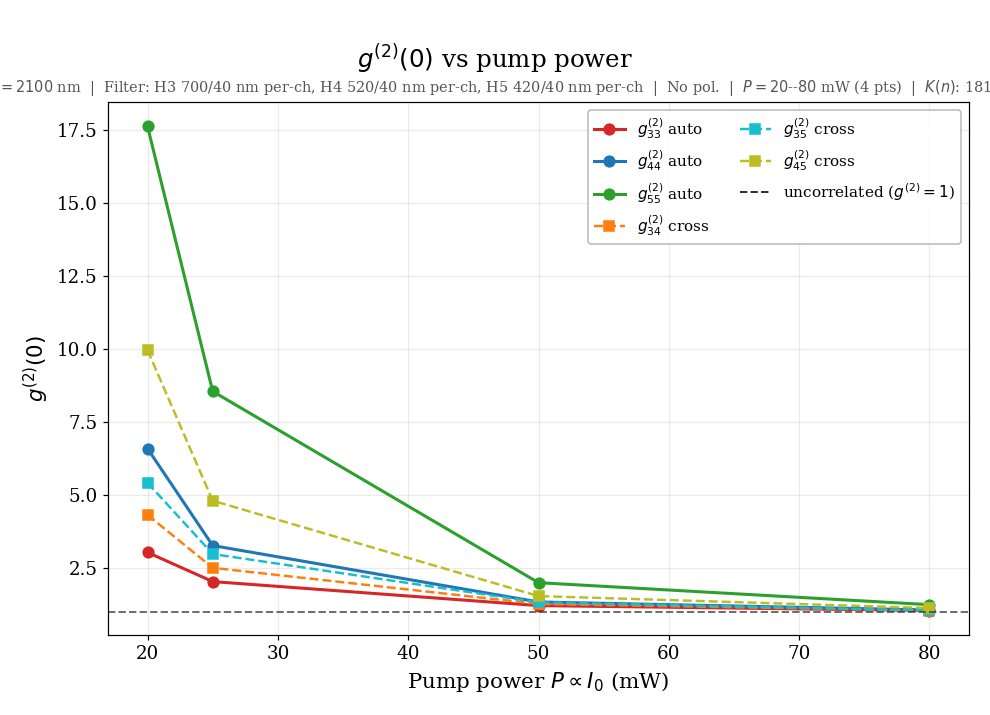

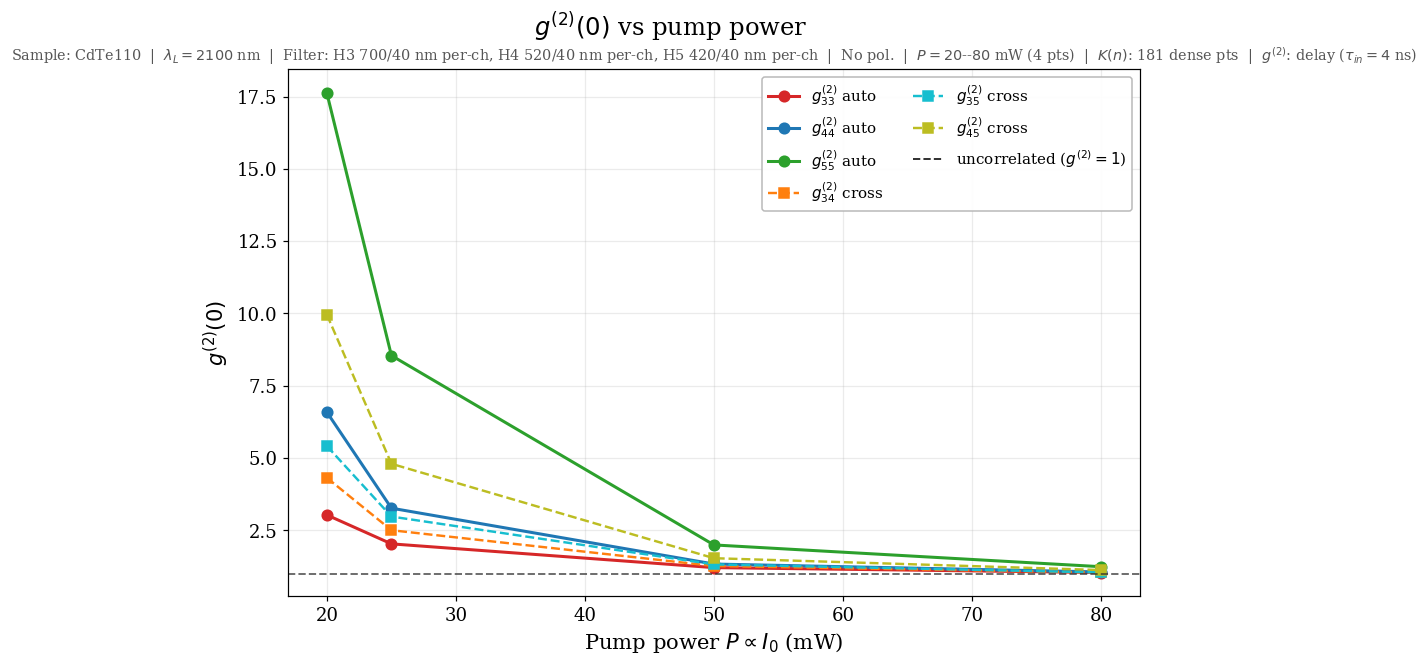

In [8]:
# g2(0) vs power, per harmonic (+ cross pairs). ylim=None auto-scales; e.g. ylim=(0.9, 5).
fig, _ = a.plot_g2_vs_power(harmonics=HARMONICS, include_cross=True, ylim=None)
rep.save(fig, "g2_vs_power")

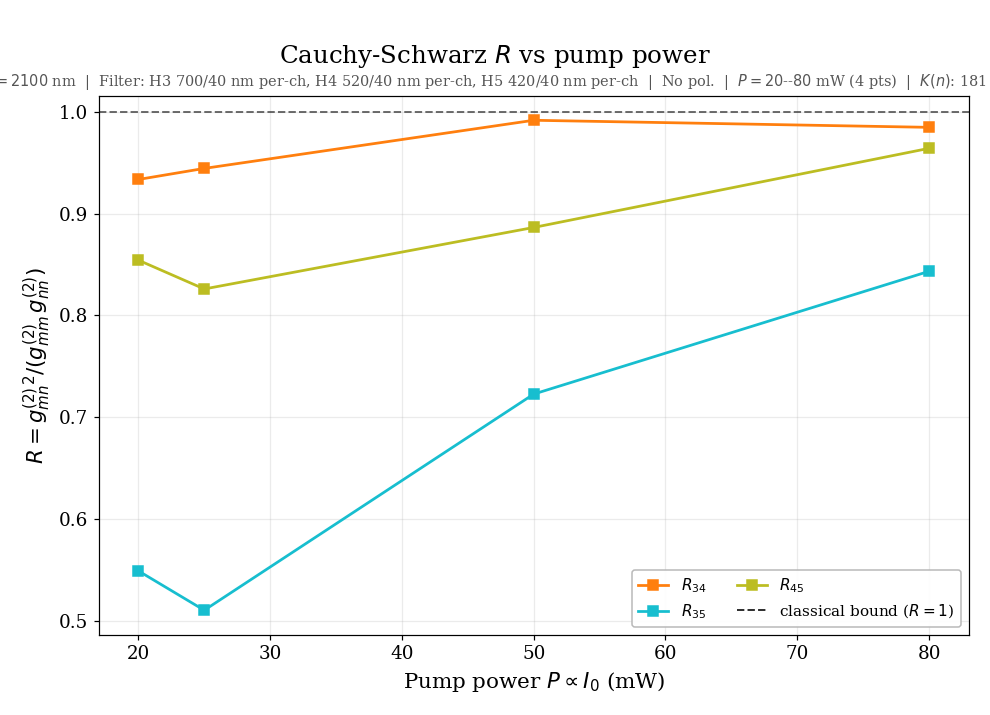

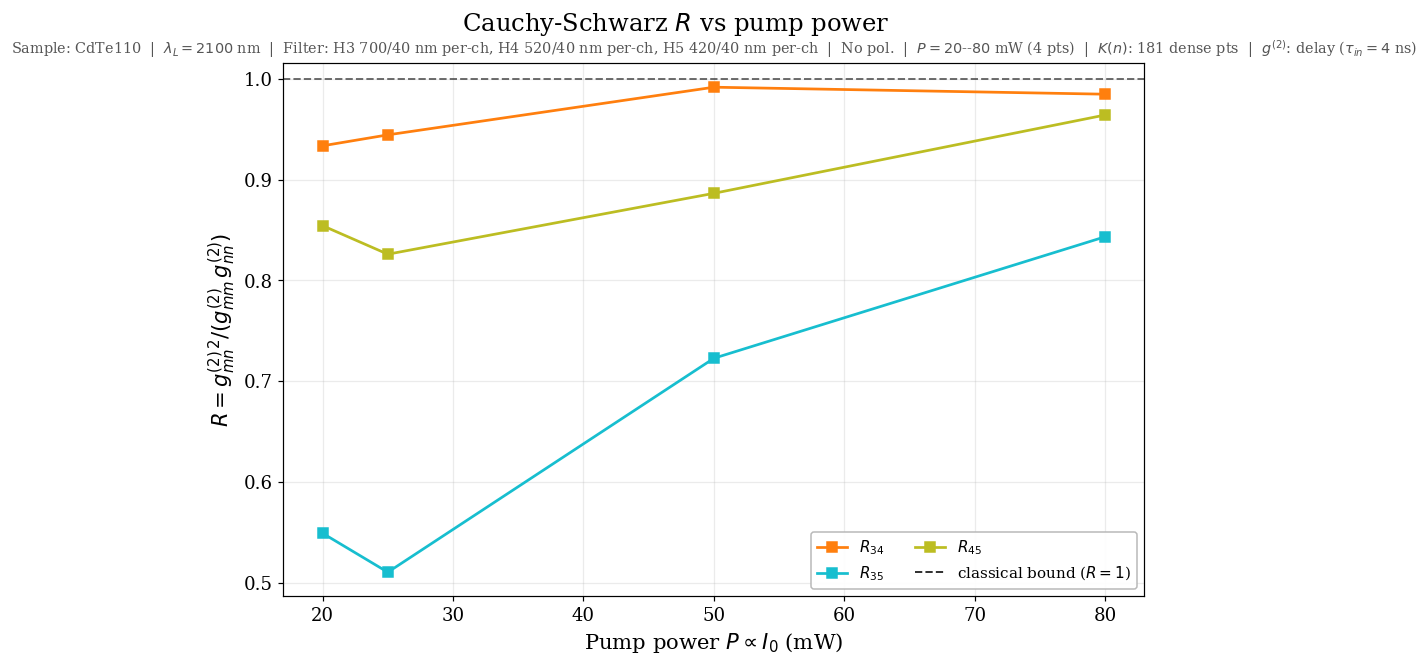

In [9]:
# Cauchy-Schwarz R vs power, one curve per cross pair.
fig, _ = a.plot_R_vs_power(harmonics=HARMONICS, ylim=None)
rep.save(fig, "R_vs_power")

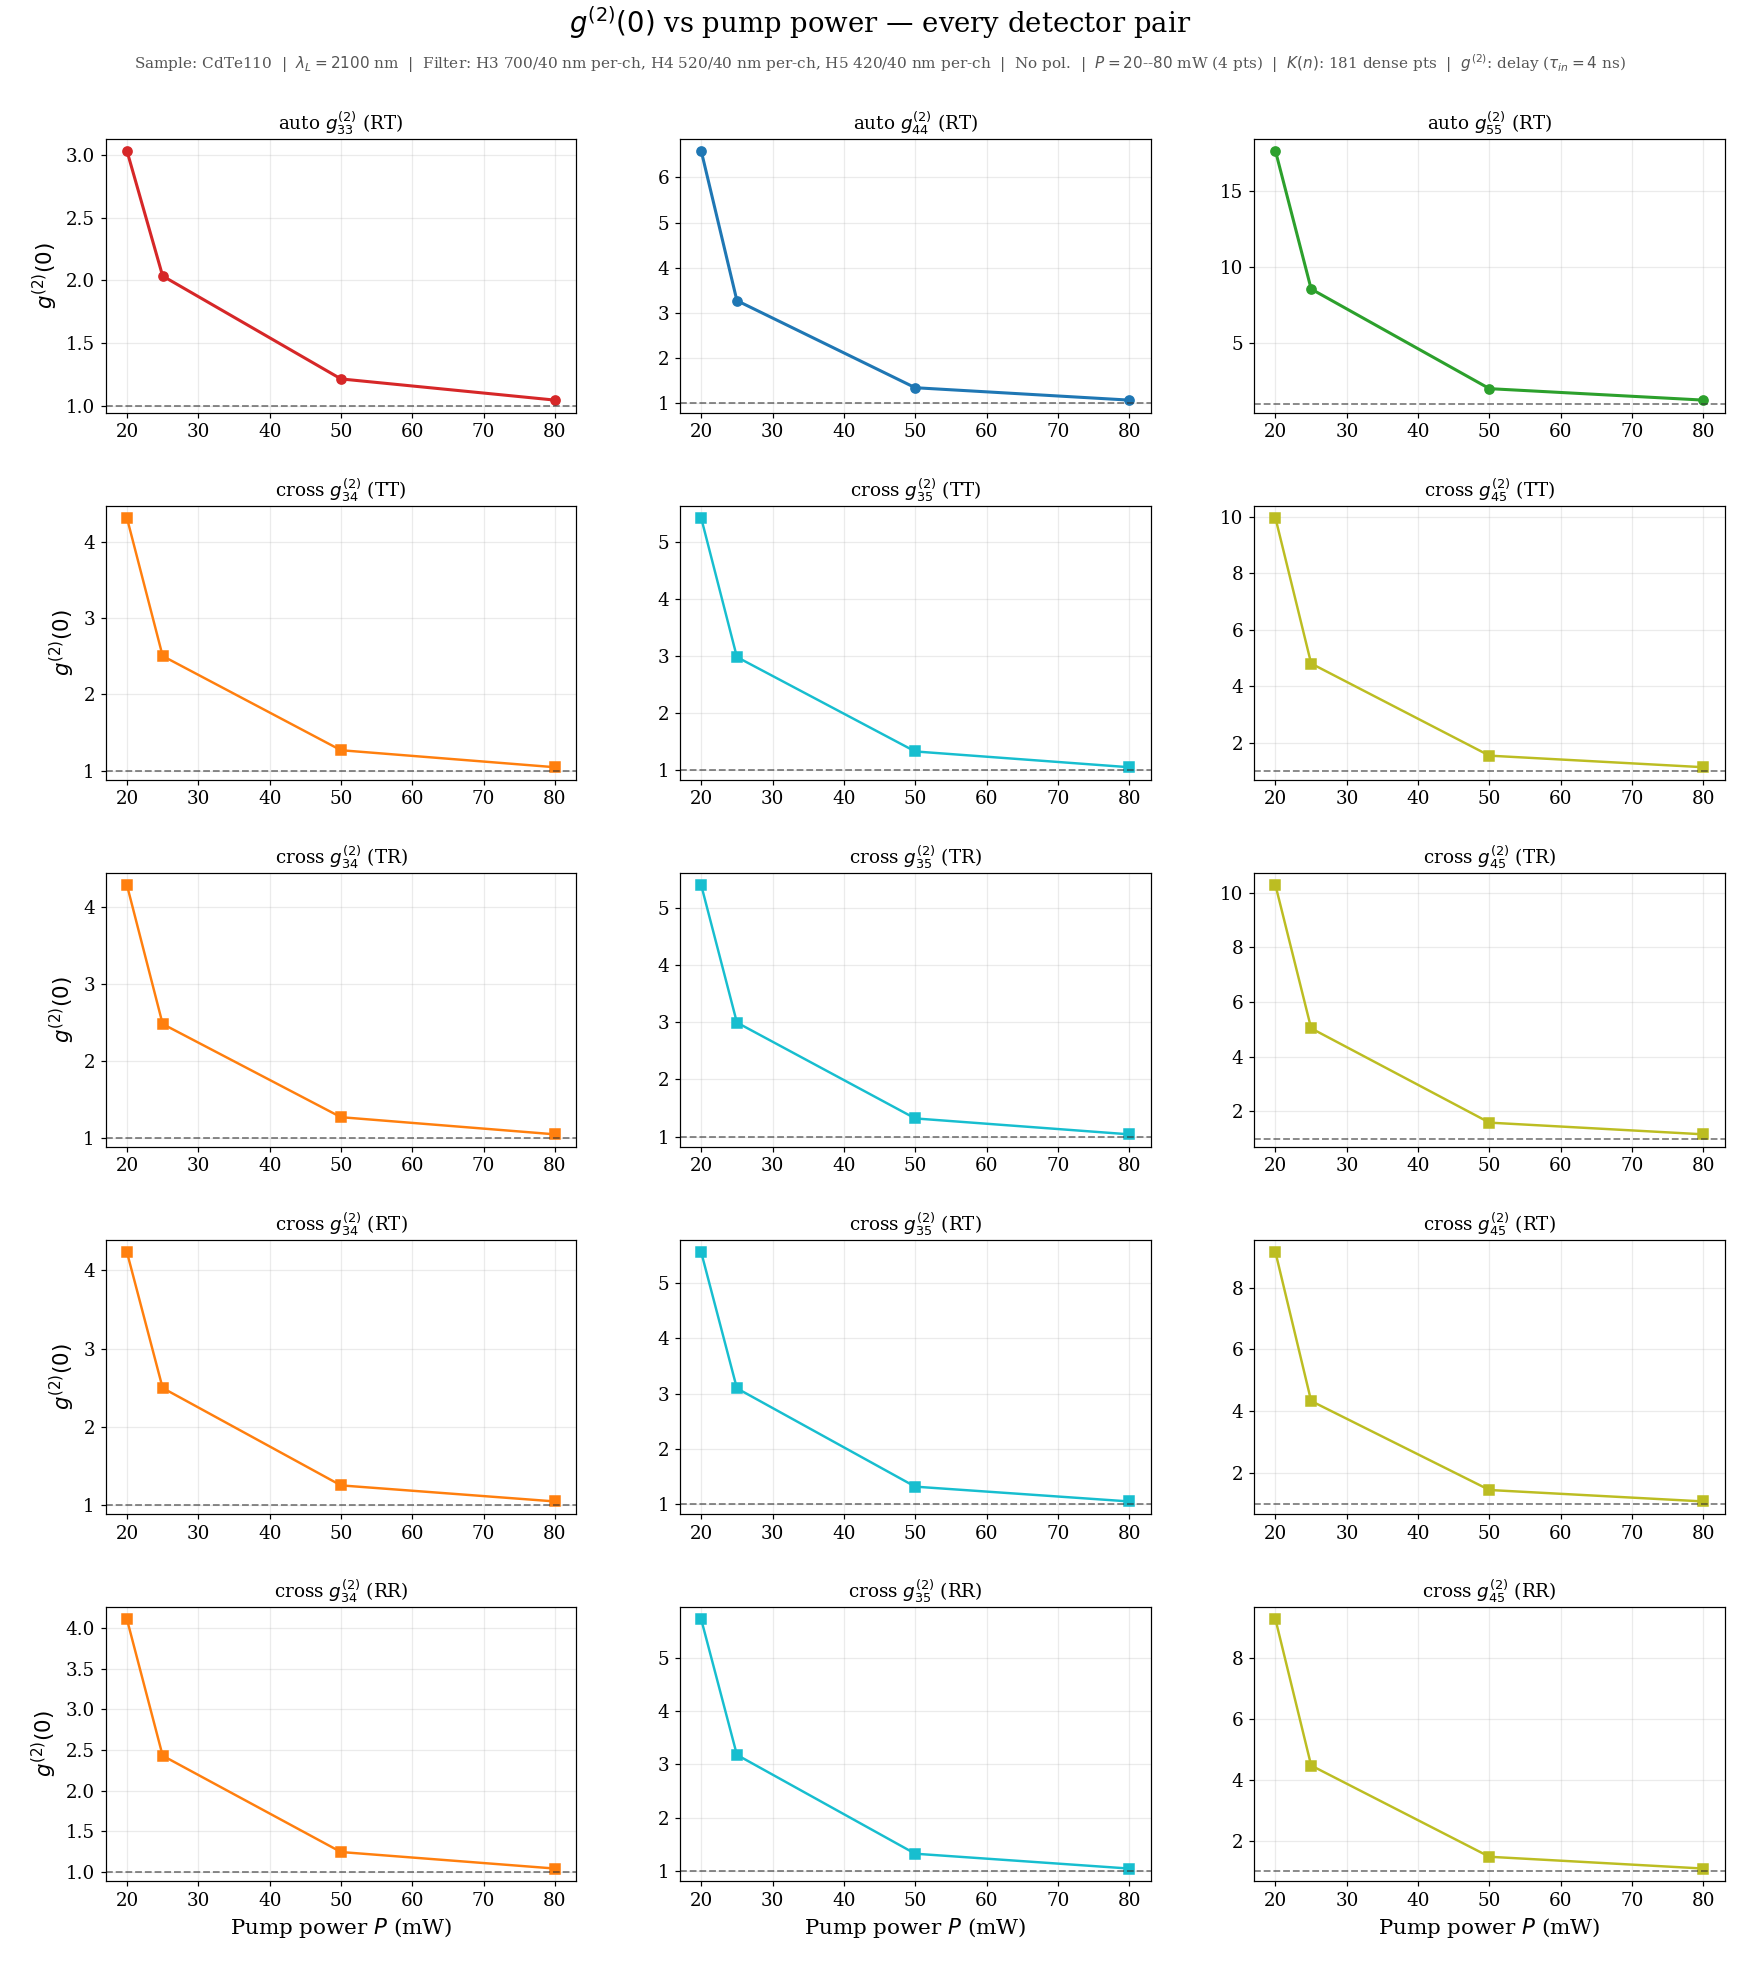

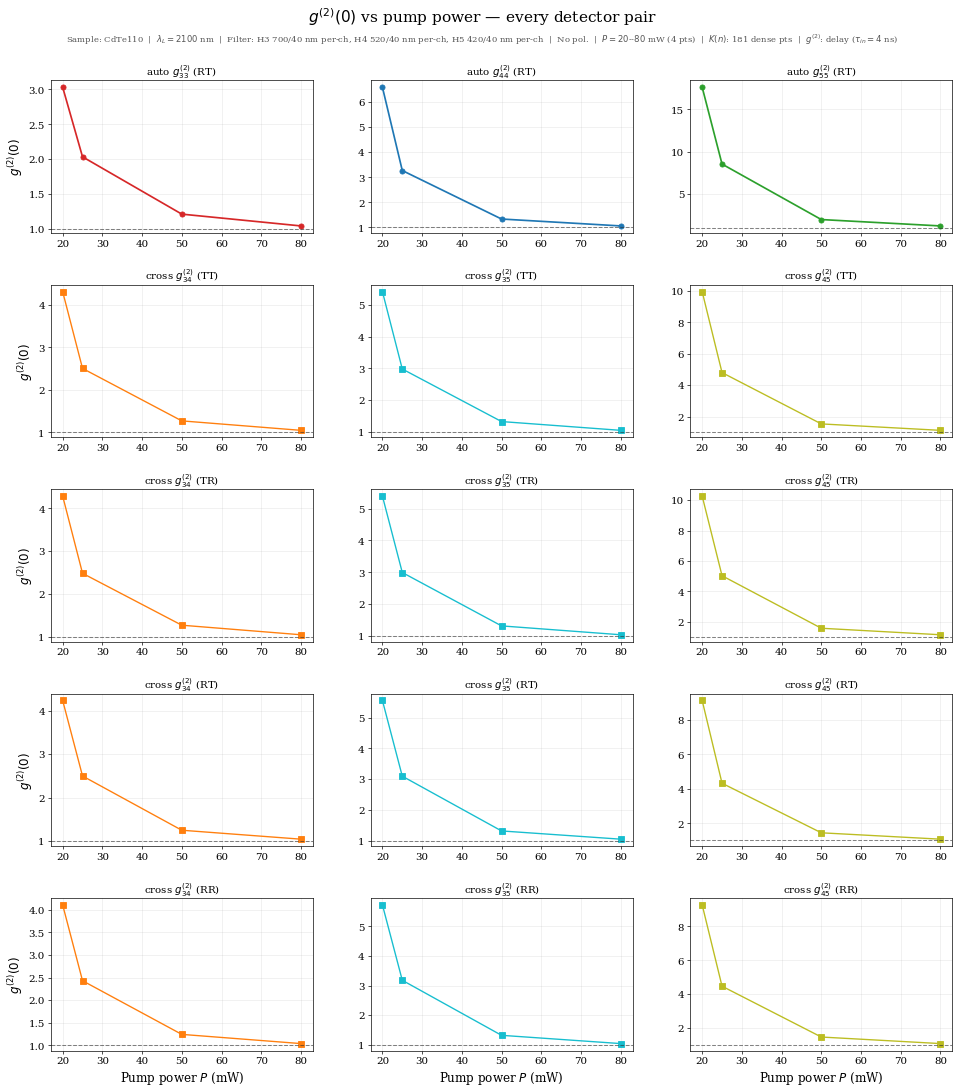

In [10]:
# g2(0) vs power for EVERY detector pair: auto row + cross TT/TR/RT/RR rows.
fig, _ = a.plot_g2_grid_vs_power(ylim=None)
rep.save(fig, "g2_grid_vs_power")

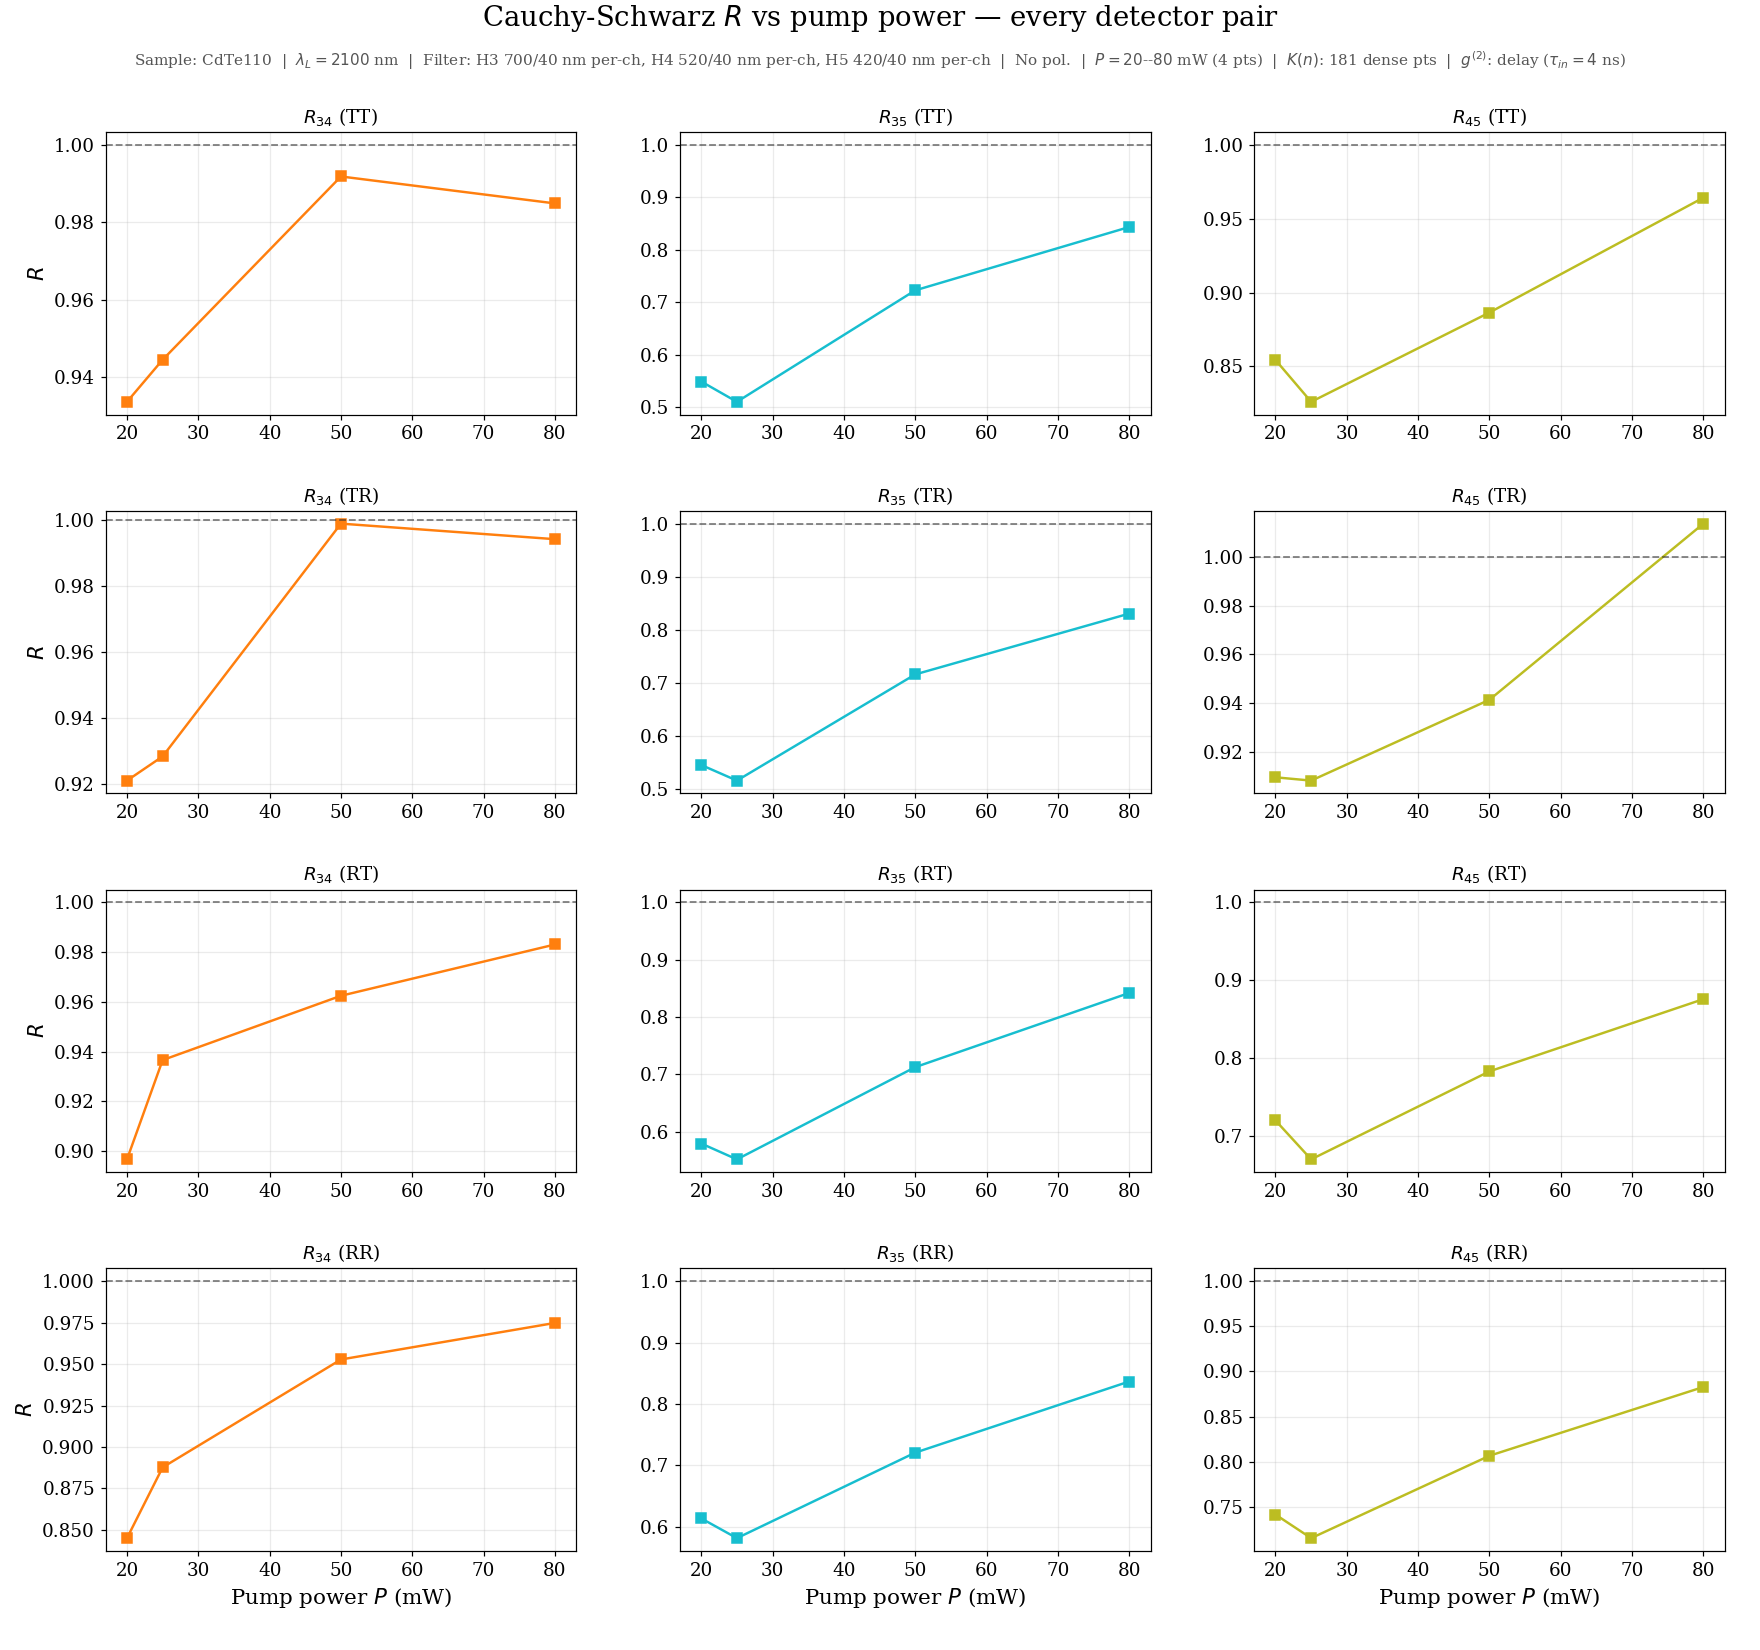

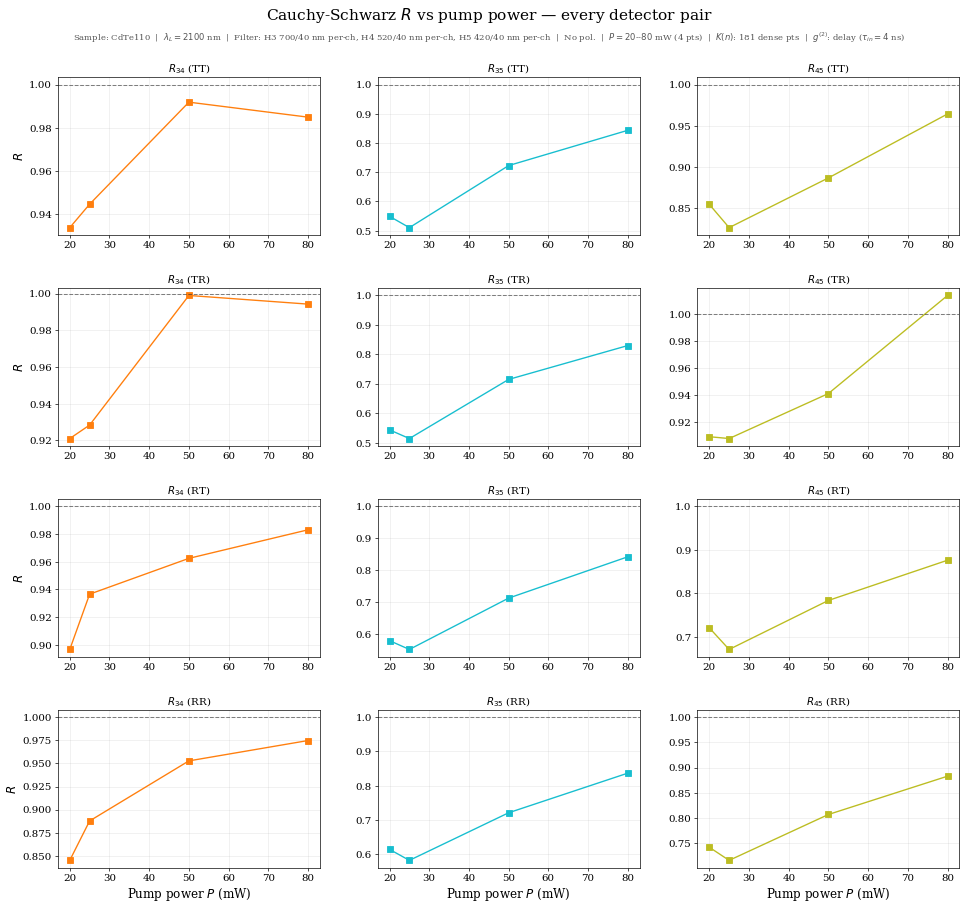

In [11]:
# R vs power for every cross pair and arm combination (TT/TR/RT/RR).
fig, _ = a.plot_R_grid_vs_power(ylim=None)
rep.save(fig, "R_grid_vs_power")

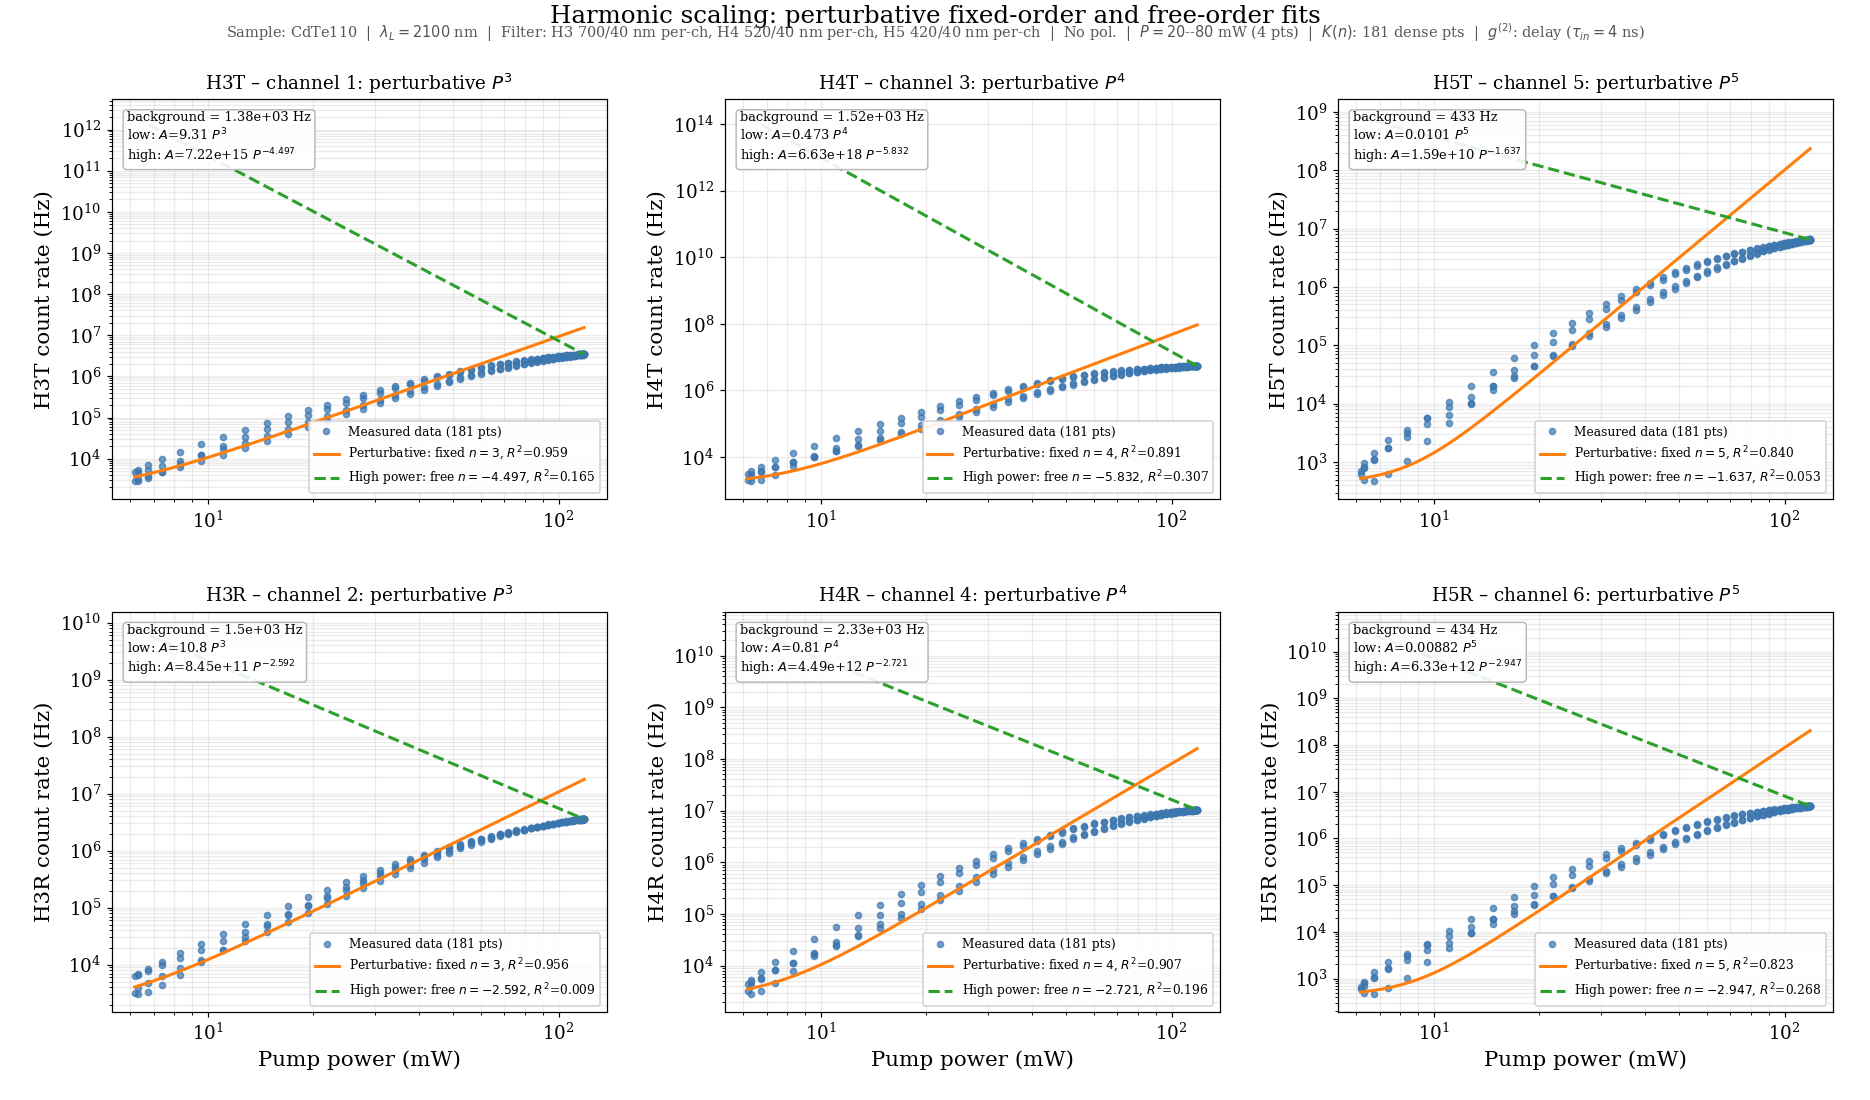

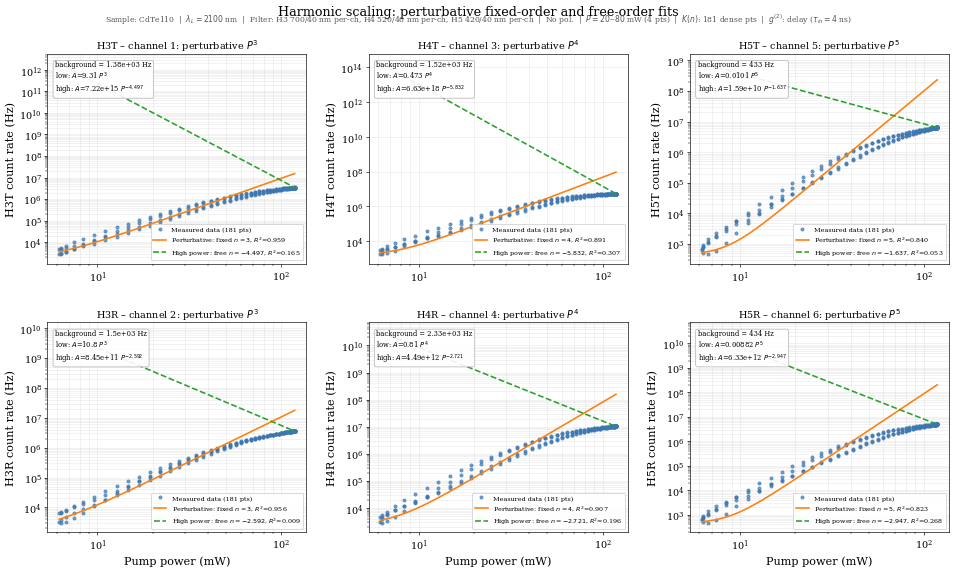

In [12]:
# Per-channel intensity scaling: dense (or normal) points + perturbative fixed-P^n fit
# (with background) + free-order fit of the last n_high points.
#   dense_stride : 1 = plot EVERY dense point, 2 = every other, ...   (fits use all points)
#   max_points   : cap the markers to this many, evenly spaced (None = no cap)
#   frac_low     : fraction of low-power points used for the fixed-order P^n fit
#   n_high       : how many high-power points the free fit uses
fig, _ = a.plot_intensity_grid(harmonics=HARMONICS, dense_stride=1, max_points=None, frac_low=0.6, n_high=5, r2_min=0.5, xlim=None, ylim=None)
rep.save(fig, "intensity_grid")

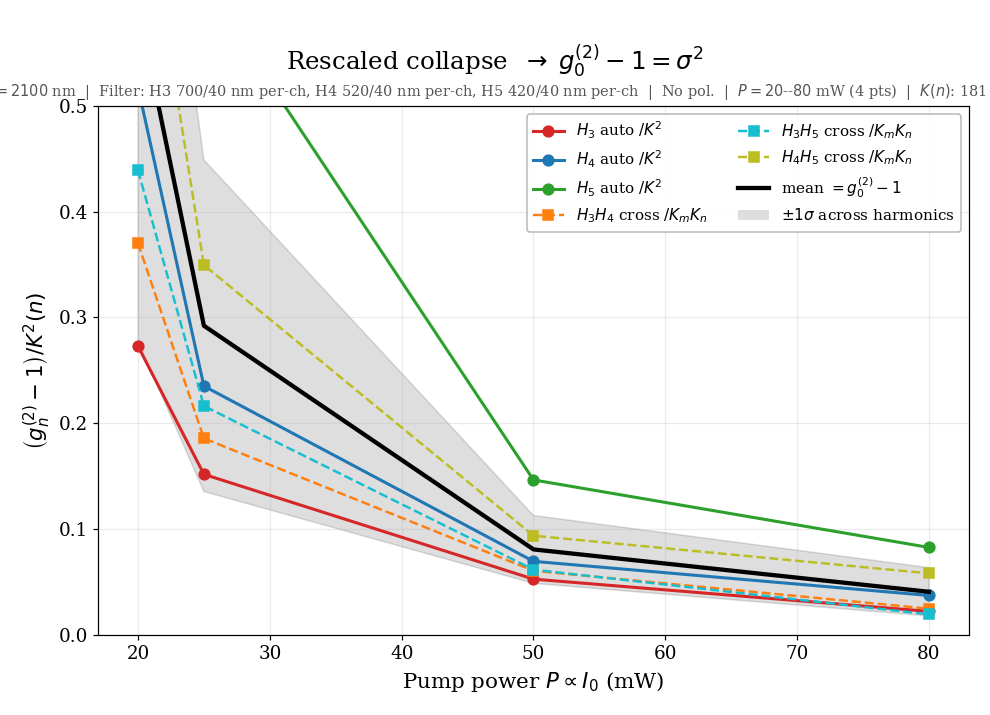

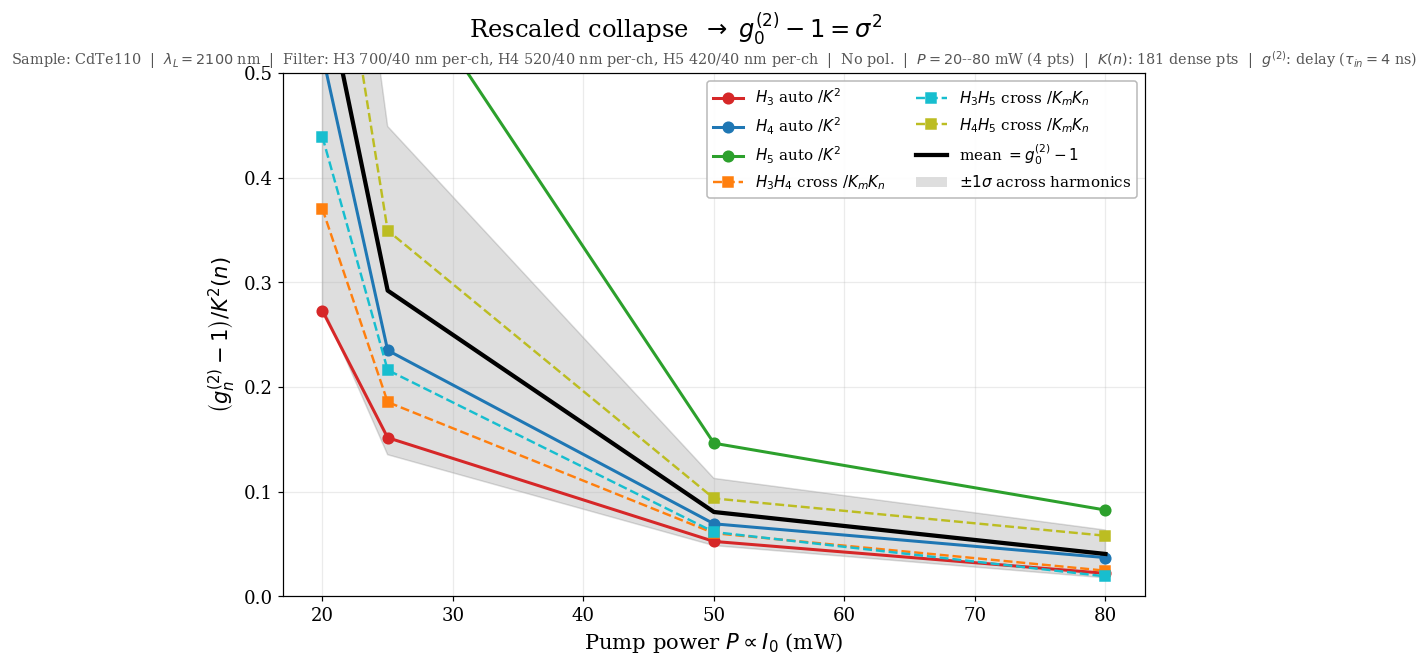

In [19]:
# Rescaled collapse (g2-1)/K^2  ->  sigma^2 = g2_0 - 1.
fig, _ = a.plot_g2_collapse(slope="local", include_cross=True, harmonics=HARMONICS,
                            ylim=(0, 0.5))
rep.save(fig, "collapse")

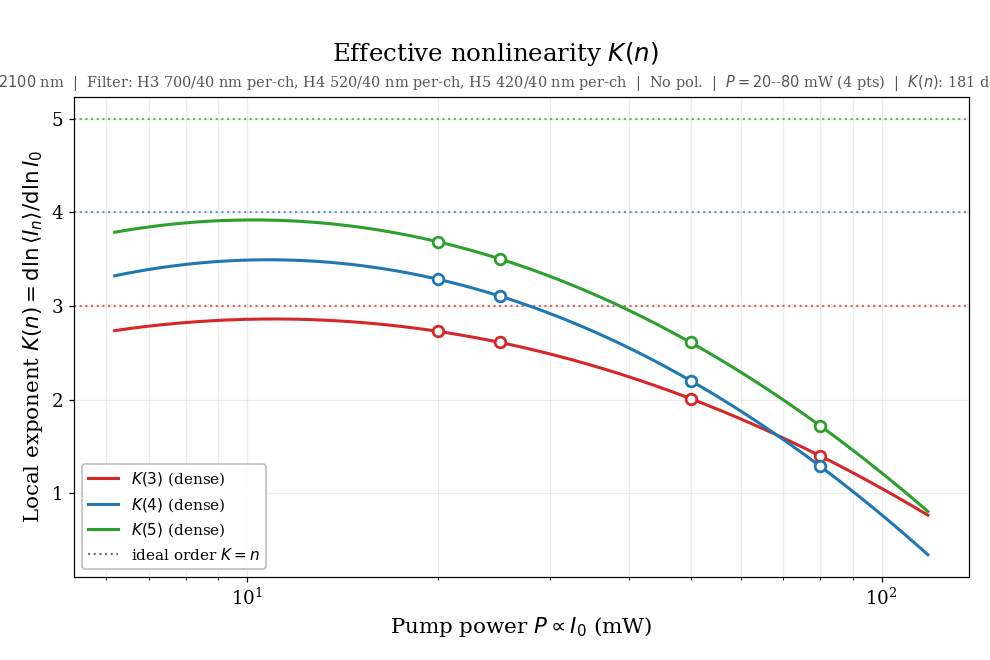

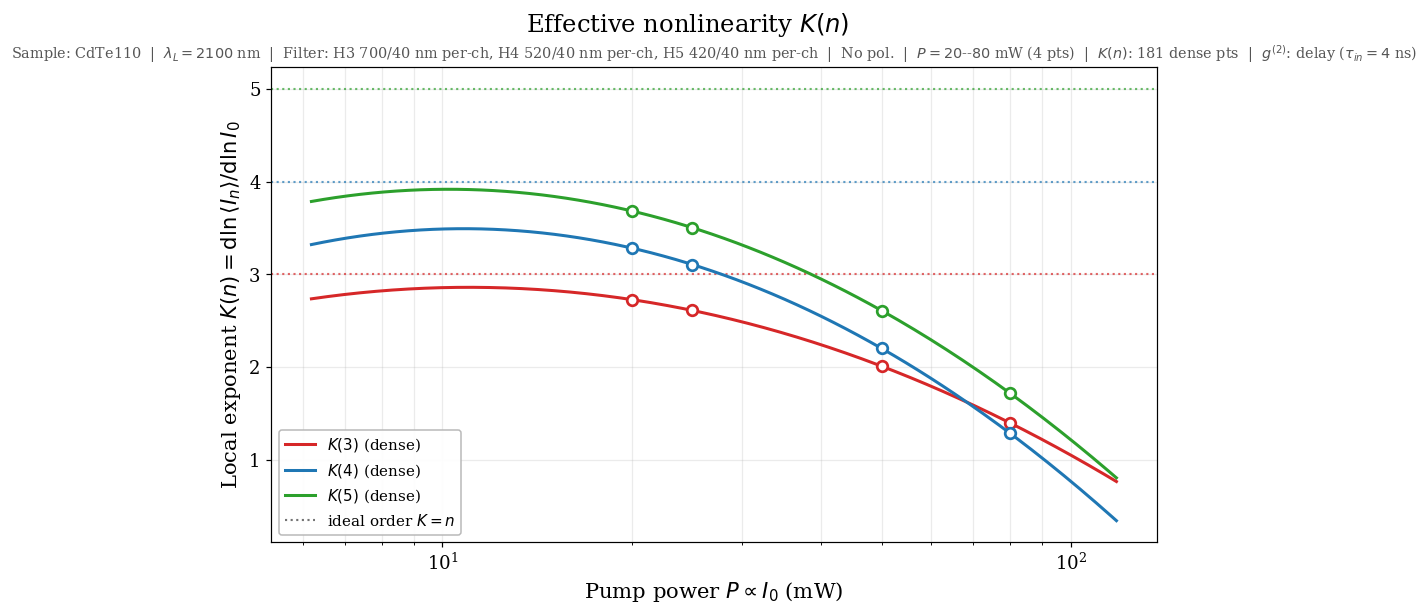

In [14]:
# Effective nonlinearity K(n) vs power (dense smooth curve when a dense scan exists).
fig, _ = a.plot_local_slope(ylim=None)
rep.save(fig, "local_slope")

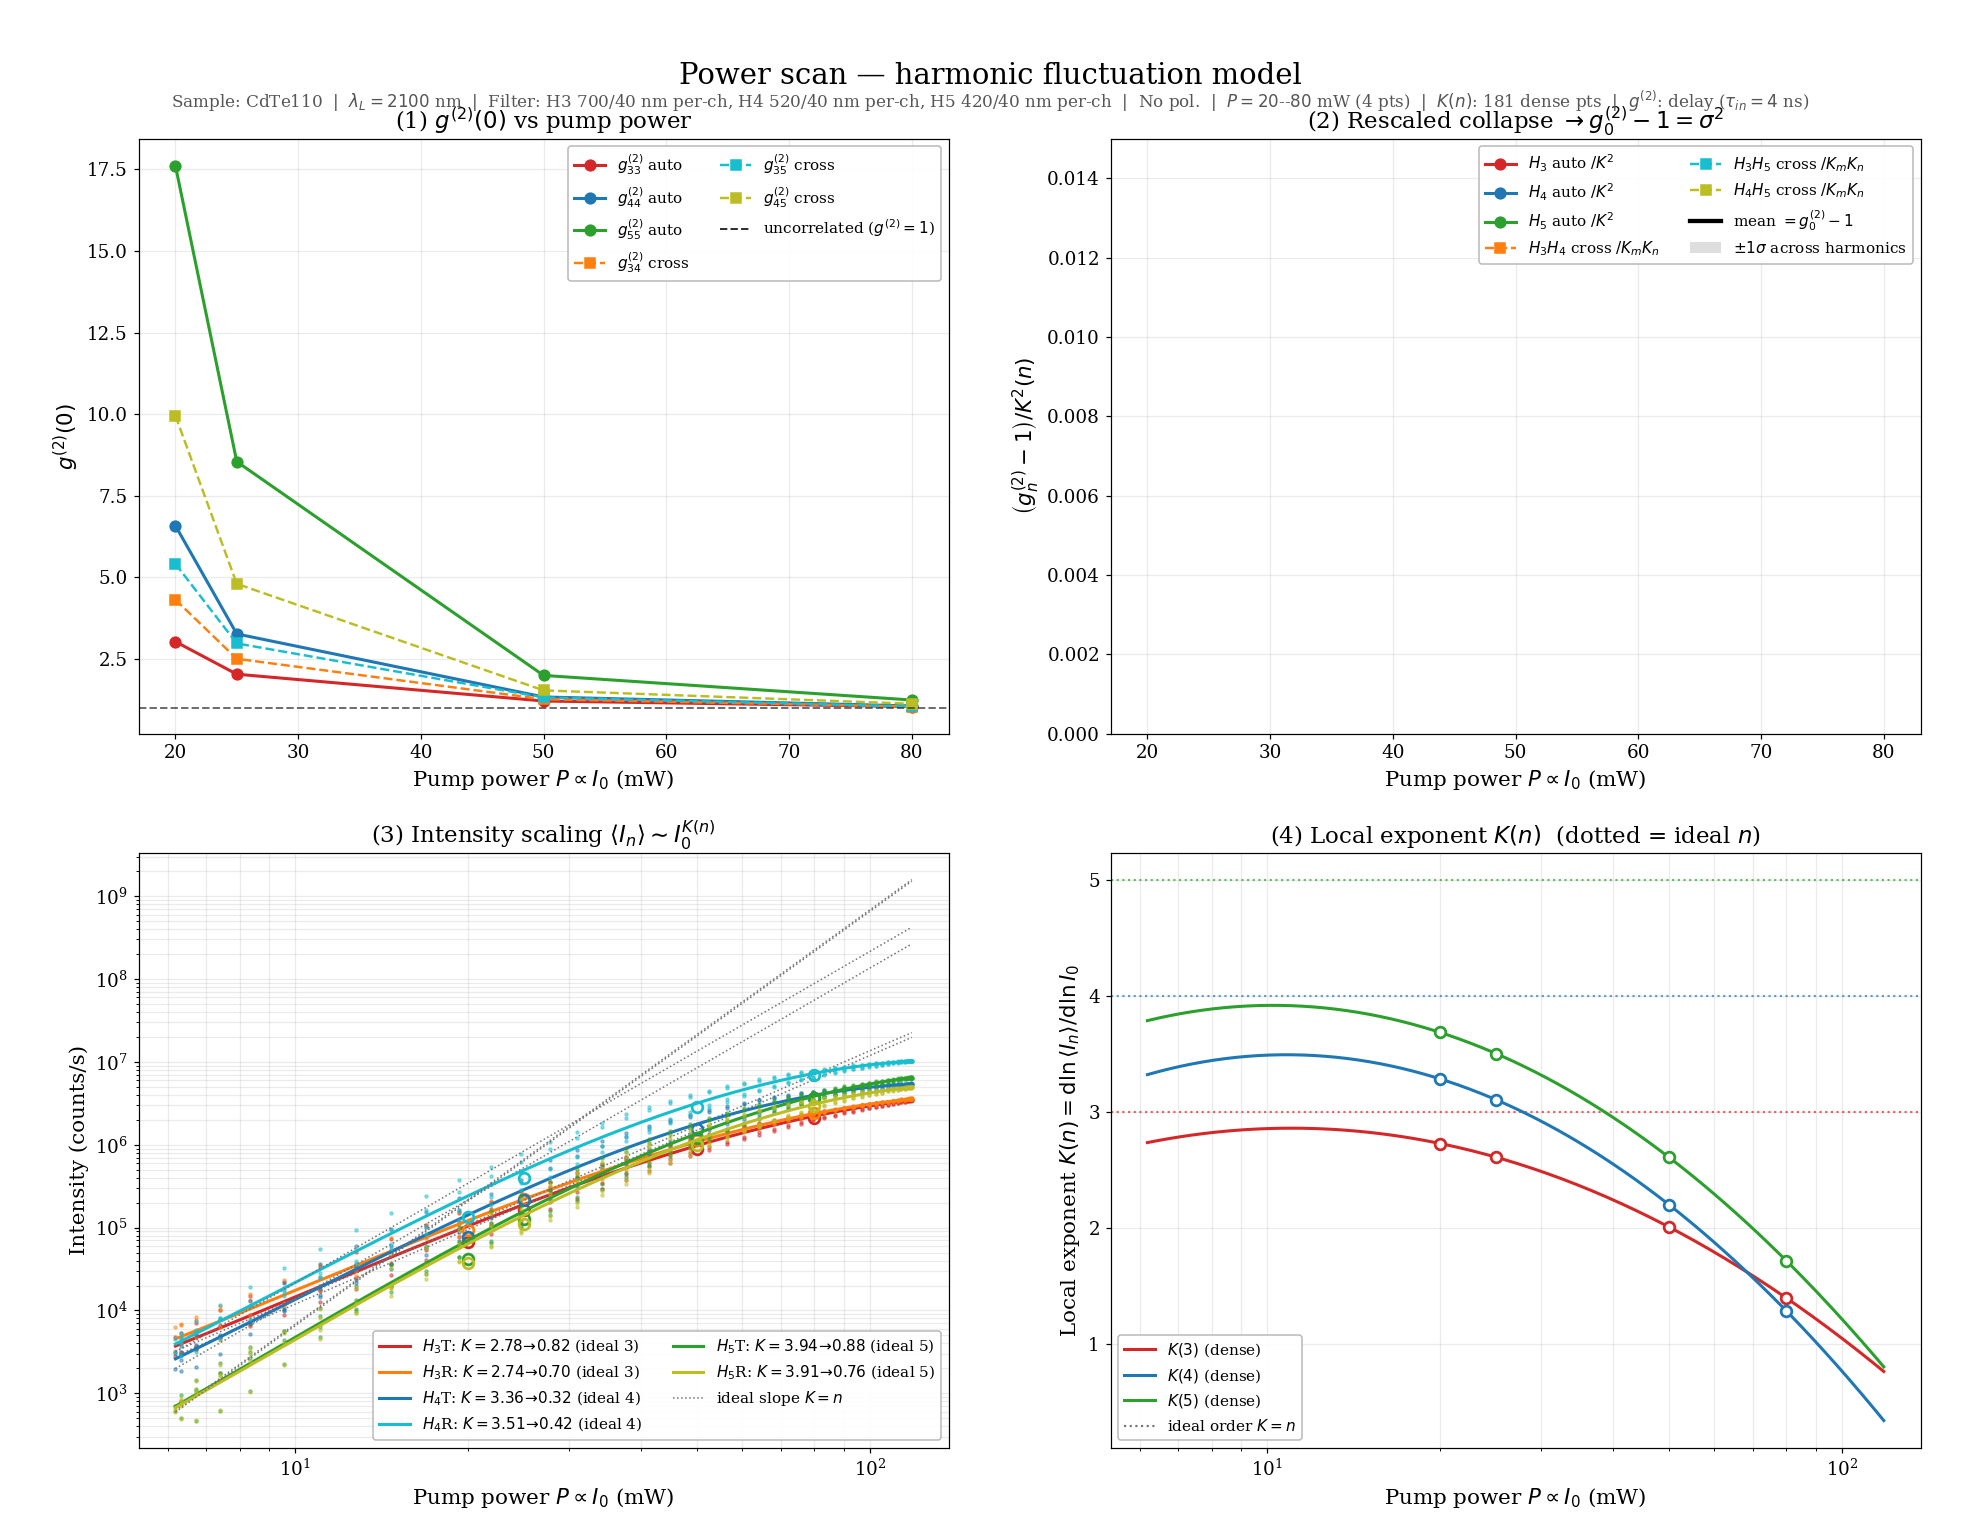

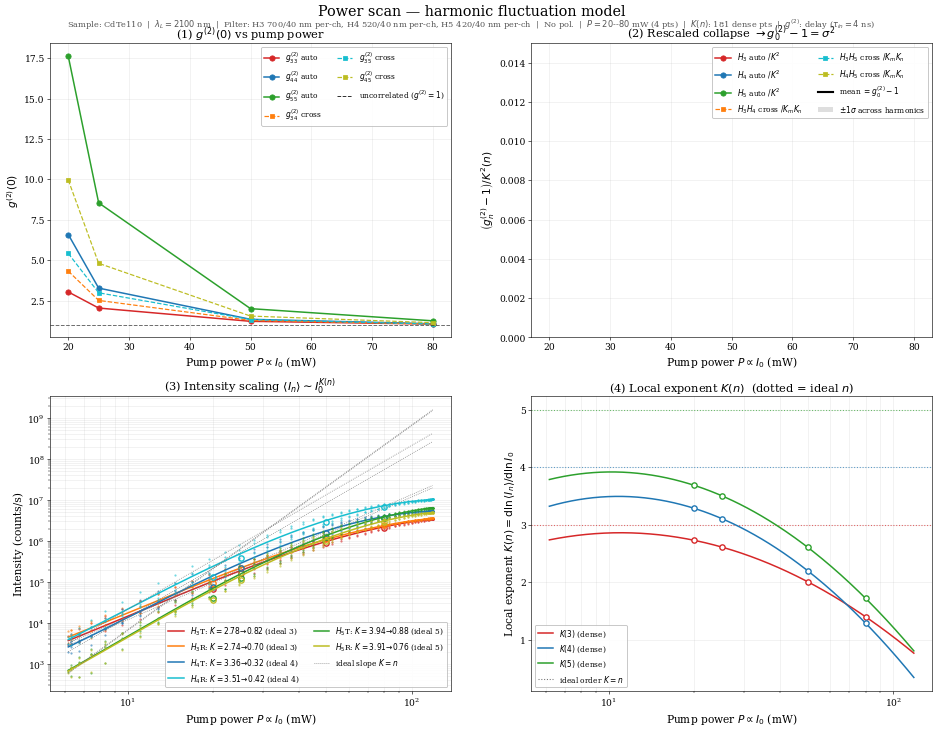

In [ ]:
# Optional 2x2 dashboard (g2 vs power, collapse, intensity scaling, K(n)).
fig, _ = a.plot_overview(harmonics=HARMONICS, g2_ylim=None)
rep.save(fig, "overview")

## 5. Correlation grids vs integration window (optional)

The g2 / R / coherence sweeps of the integration window tau_in (one grid per power).

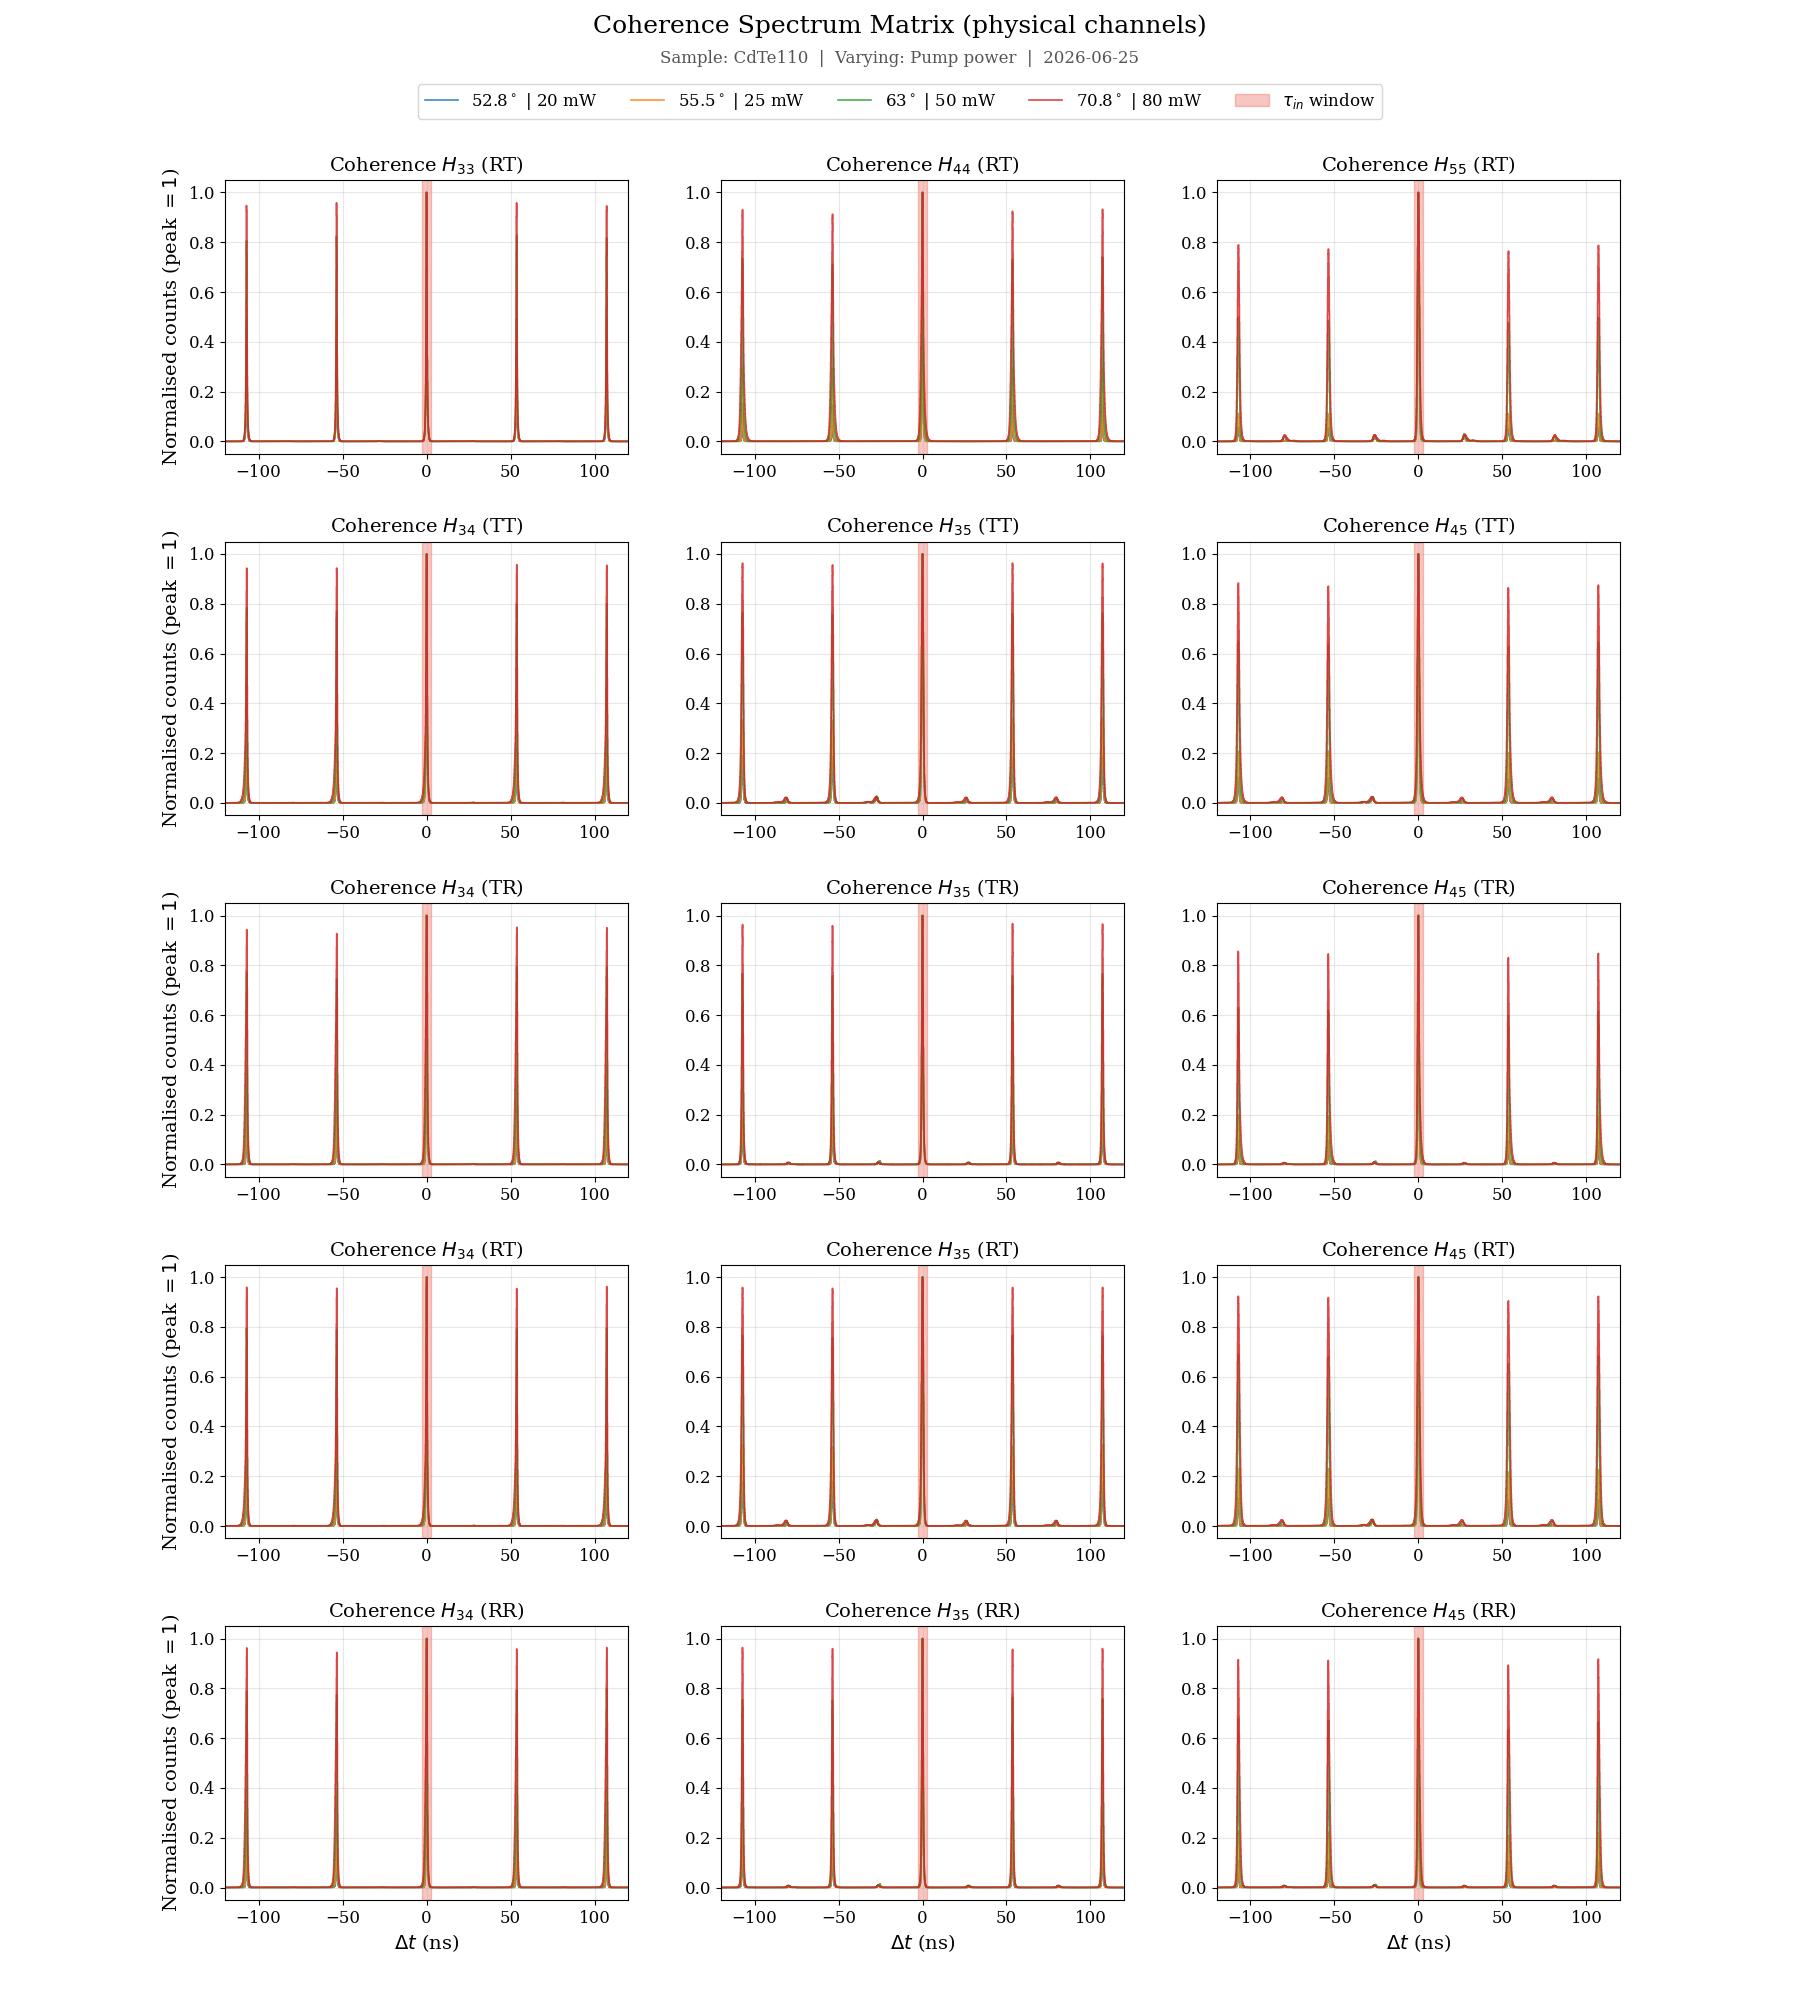

  coherence -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\results\CdTe110\POWESCAN__20deg\2026-06-25\coherence


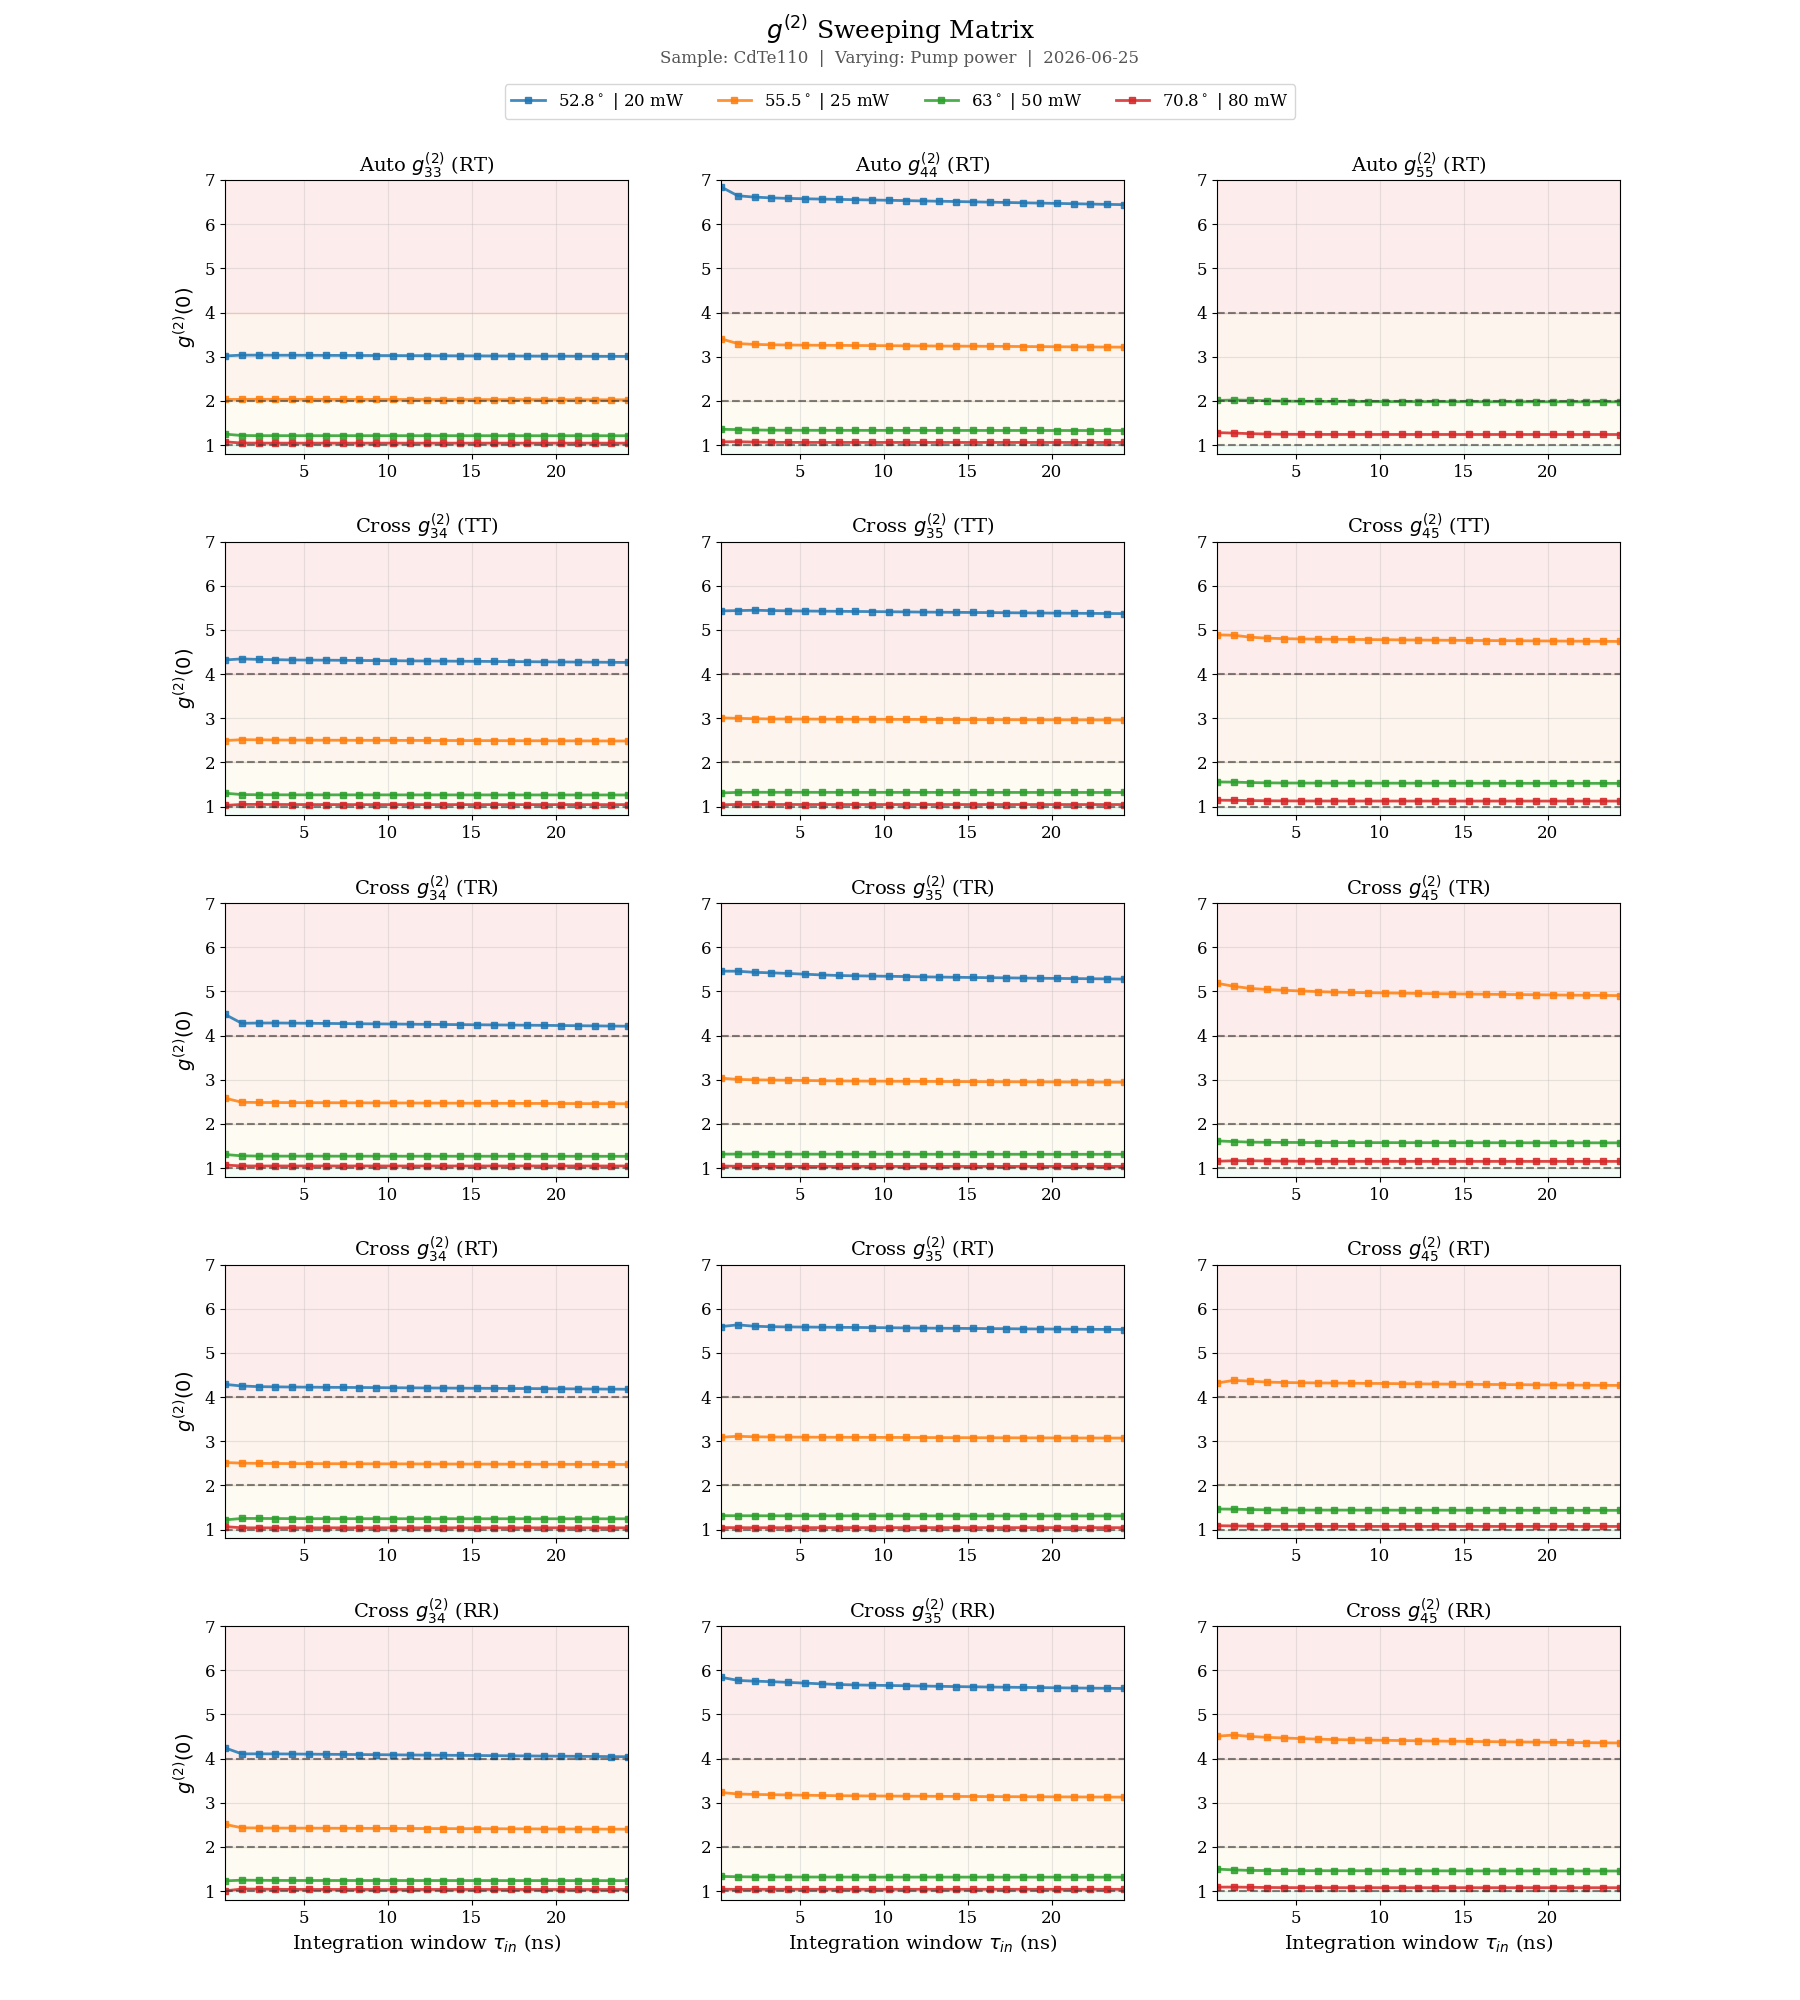

  g2        -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\results\CdTe110\POWESCAN__20deg\2026-06-25\g2


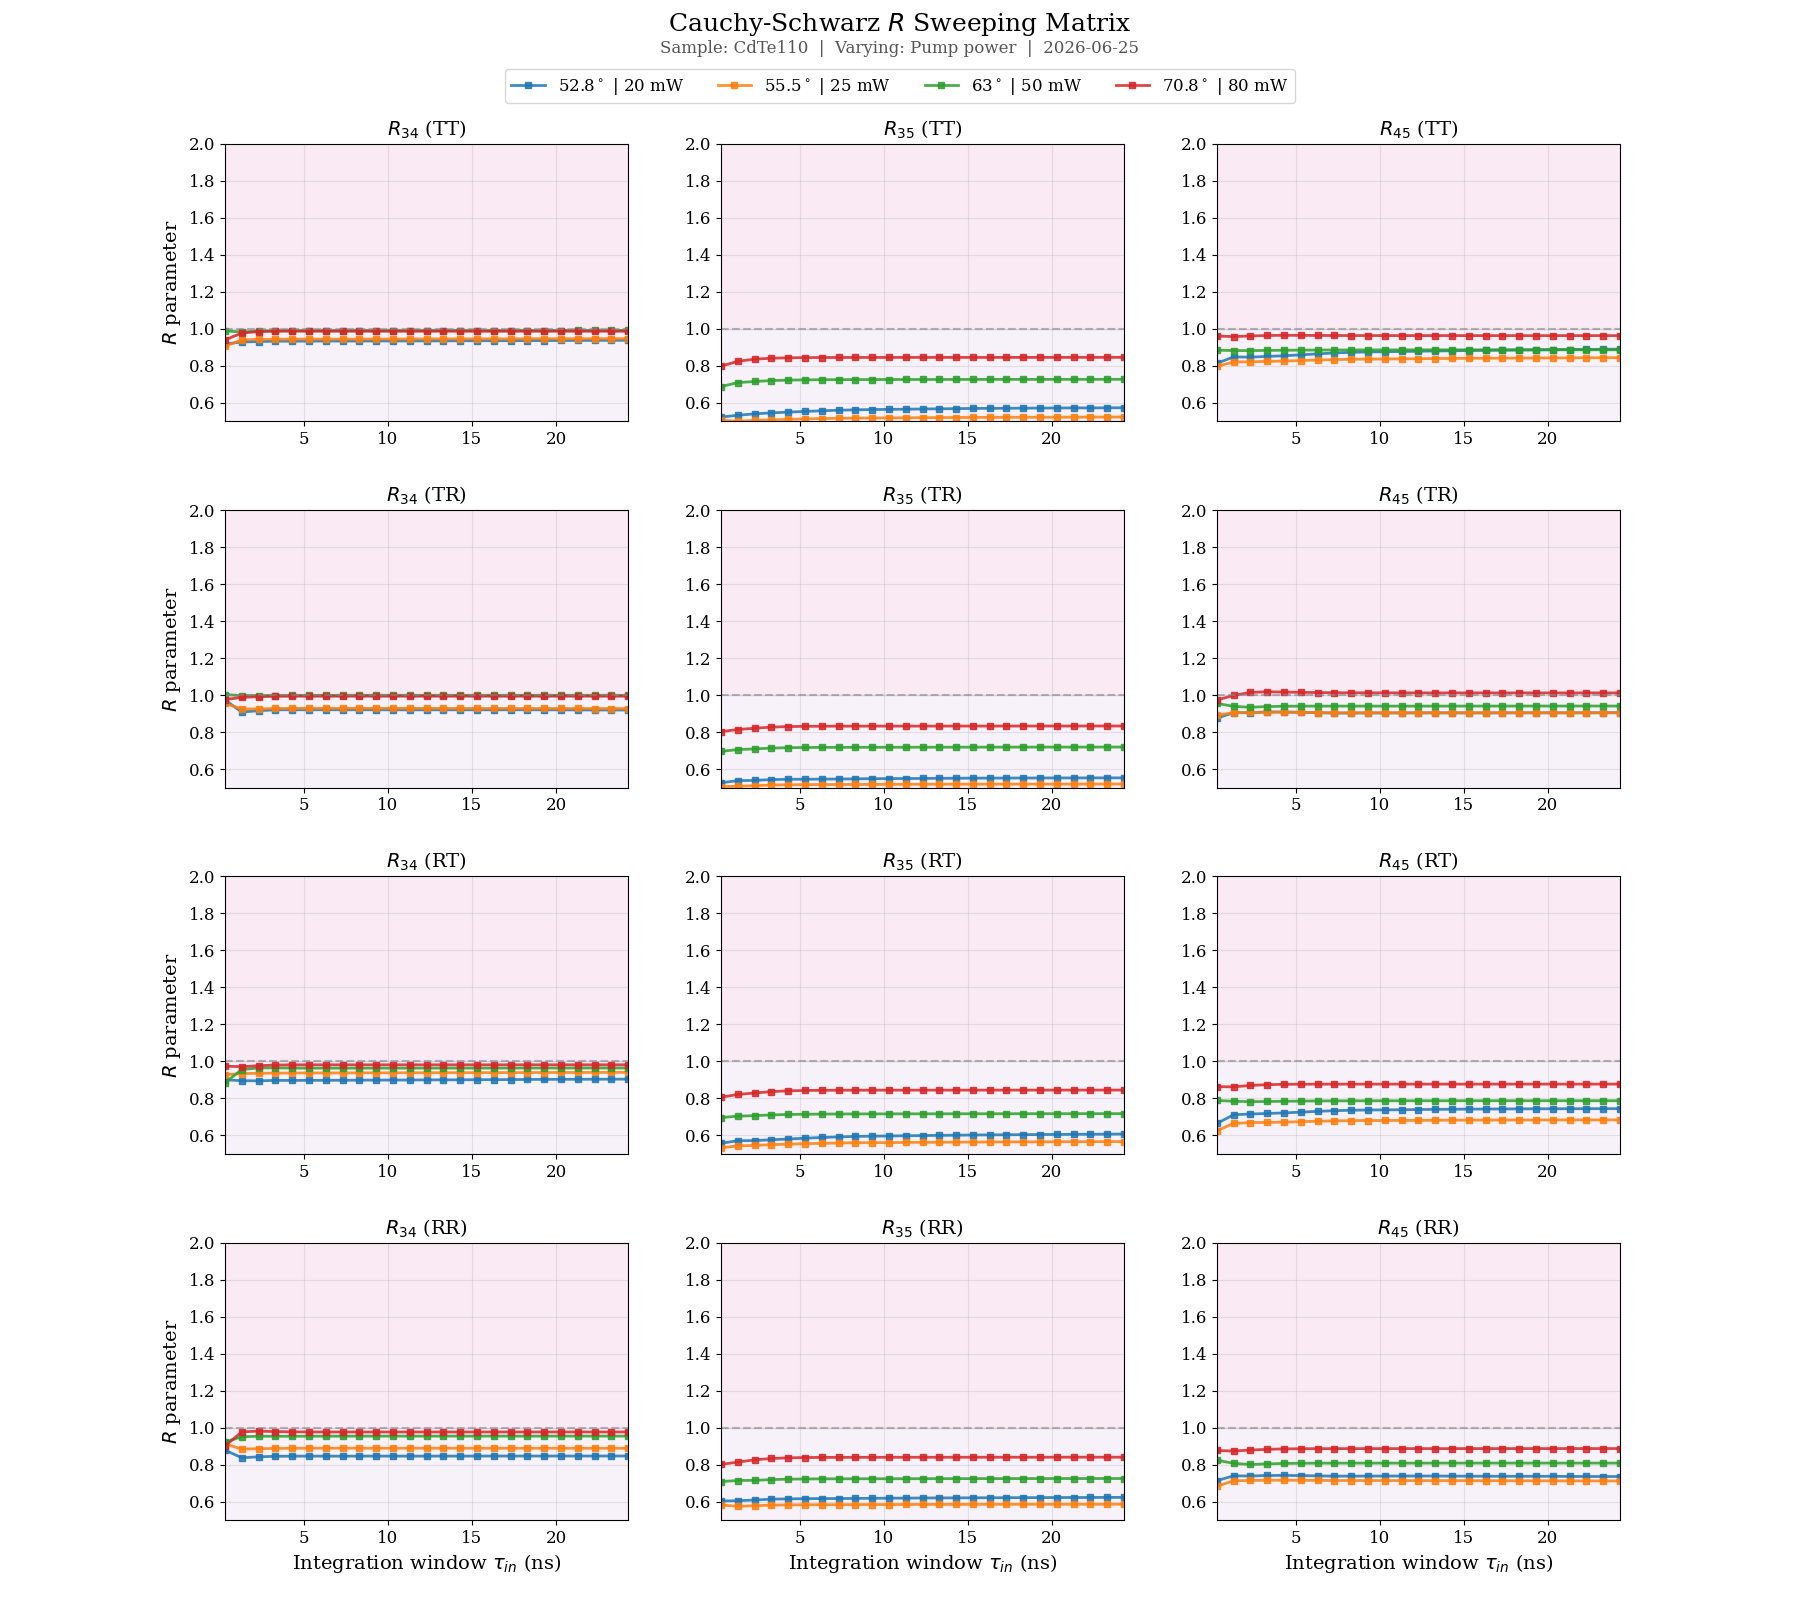

  R         -> c:\Users\QUANTUM\OneDrive - ENSTA\!Working files\HBT\Simon_Code\results\CdTe110\POWESCAN__20deg\2026-06-25\R


In [16]:
rep.correlations(
    coherence=dict(xlim=120, integration_window_ns=5.0),
    g2=dict(methods=["delay"], ylim=(0.8, 7), tau_min=0.3, tau_max=25, step=1.0, num_side_peaks=5),
    R=dict(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, ylim=(0.5, 2)))

## 6. Quick zoom

Re-render any single plot with explicit limits, or drag on a widget figure to zoom.

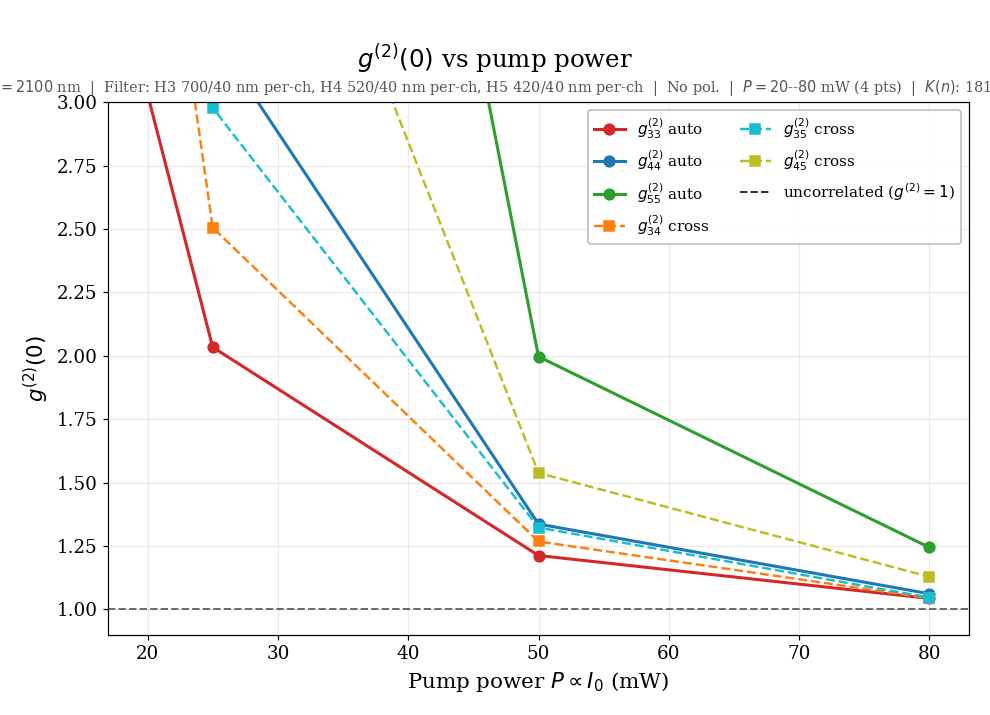

In [17]:
fig, ax = a.plot_g2_vs_power(harmonics=HARMONICS, include_cross=True, ylim=(0.9, 3))
rep._display(fig)